# Model Evaluation — Test-Set Analysis & Final Results

**Course:** Accelerated Machine Learning  
**Notebook:** 3 of 3 — `ModelEvaluation.ipynb`  
**Dataset:** HIGGS — UCI Machine Learning Repository (Baldi, Sadowski & Whiteson, 2014)  
**Date:** April 2026

---

## Pipeline Position

| Notebook | Role | Status |
|----------|------|--------|
| `DataAnalysis.ipynb` | EDA, feature selection | Complete |
| `ModelTraining.ipynb` | Data preparation, training, tuning, serialisation | Complete |
| **`ModelEvaluation.ipynb`** | **Test-set evaluation, visualisation, discussion** | **This notebook** |

## Purpose

This notebook performs the **first and only evaluation on the locked test set** (1,650,000 rows). All model selection, hyperparameter tuning, and threshold decisions were finalised in the training stage. No retraining, re-tuning, or threshold optimisation is performed here.

**Primary metric:** Macro F1-score — consistent with all prior stages.

**What this notebook produces:**

1. Test-set metrics (F1, precision, recall, accuracy) for the selected model and ensemble variants
2. Classification report, confusion matrix, ROC curve, and Precision-Recall curve
3. Feature importance analysis (XGBoost gain, weight, cover)
4. Model comparison table (test set)
5. Generalisation check (validation vs test F1)
6. Error analysis and academic discussion

---

## 1. Imports & Environment Setup

All artefacts were produced by `ModelTraining.ipynb` using the RAPIDS GPU stack (cuDF, cuML, CuPy) on a Quadro RTX 8000 (48 GB VRAM). This evaluation notebook uses scikit-learn for all metric computation and matplotlib for visualisation. GPU libraries are imported for ensemble base-model inference where required.

**Known constraint:** cuML `RandomForestClassifier` does not expose `feature_importances_` in RAPIDS 23.08. Feature importance analysis uses XGBoost's native importance methods only.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.colors as mcolors
import time
import os
import pickle
import warnings
import joblib
import gc

from xgboost import XGBClassifier
from sklearn.metrics import (
    f1_score, precision_score, recall_score, accuracy_score,
    classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve, average_precision_score
)

try:
    import cupy as cp
    import cudf
    import cuml
    from cuml.ensemble import RandomForestClassifier as cuRF
    from cuml.linear_model import LogisticRegression as cuLR
    RAPIDS_AVAILABLE = True
    print(f"cuDF    : {cudf.__version__}")
    print(f"cuML    : {cuml.__version__}")
except ImportError:
    RAPIDS_AVAILABLE = False
    print("RAPIDS not available — ensemble GPU base models will be skipped.")

warnings.filterwarnings("ignore")
os.makedirs("plots", exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(f"\nNumPy   : {np.__version__}")
print(f"Pandas  : {pd.__version__}")
print(f"Matplotlib: {matplotlib.__version__}")

if RAPIDS_AVAILABLE:
    gpu_mem = cp.cuda.Device(0).mem_info
    print(f"\nGPU memory: {gpu_mem[1] / 1e9:.1f} GB total, {gpu_mem[0] / 1e9:.1f} GB free")

cuDF    : 23.08.00
cuML    : 23.08.00

NumPy   : 1.24.4
Pandas  : 1.5.3
Matplotlib: 3.7.2

GPU memory: 51.5 GB total, 50.1 GB free


---

## 2. Load Trained Artefacts

All artefacts were serialised by `ModelTraining.ipynb` into the `artefacts/` directory. The test set has been **locked** throughout the preceding notebooks — this cell marks the first and only time it is loaded for evaluation.

| Artefact | Format | Purpose |
|----------|--------|---------|
| `best_model.json` | XGBoost native | Tuned XGBoost — selected model |
| `scaler.joblib` | joblib | `StandardScaler` fitted on training set only |
| `test_data.npz` | NumPy | Locked test set (`X_test`, `y_test`) |
| `val_data.npz` | NumPy | Validation set (for comparison only) |
| `feature_list.pkl` | pickle | 27 selected feature names |
| `training_metadata.pkl` | pickle | Hyperparams, CV scores, split sizes |
| `model_comparison.csv` | CSV | Validation-set model comparison |
| `cv_results.csv` | CSV | 5-fold CV F1 scores |
| `tuning_results.csv` | CSV | Random search trial results |

In [2]:
print("=" * 55)
print(" Loading Core Artefacts")
print("=" * 55)

# 1. Training metadata
with open("artefacts/training_metadata.pkl", "rb") as f:
    metadata = pickle.load(f)
print(f"Selected model : {metadata['selected_model']}")
print(f"Val F1 (tuned) : {metadata['val_f1_tuned_xgb']:.4f}")
print(f"Val F1 (ens.)  : {metadata['val_f1_ensemble']:.4f}")
print(f"CV F1 (5-fold) : {metadata['cv_mean_f1']:.4f} +/- {metadata['cv_std_f1']:.4f}")
print(f"Split ratio    : {metadata['split_ratio']}")
print(f"Train / Val / Test : {metadata['train_size']:,} / {metadata['val_size']:,} / {metadata['test_size']:,}")

# 2. Feature list
with open("artefacts/feature_list.pkl", "rb") as f:
    features = pickle.load(f)
print(f"\nFeatures loaded: {len(features)} features")

# 3. Selected model (XGBoost)
best_model = XGBClassifier()
best_model.load_model("artefacts/best_model.json")
print(f"Model loaded   : best_model.json")

# 4. Scaler (fitted on training set only)
scaler = joblib.load("artefacts/scaler.joblib")
print(f"Scaler loaded  : {type(scaler).__name__}")

# 5. LOCKED test set — first and only access
print("\n>>> Unlocking test set for evaluation <<<")
test_data = np.load("artefacts/test_data.npz")
X_test = test_data["X_test"]
y_test = test_data["y_test"]
print(f"X_test shape   : {X_test.shape}  dtype: {X_test.dtype}")
print(f"y_test shape   : {y_test.shape}  dtype: {y_test.dtype}")
print(f"Class balance  : {(y_test == 1).sum():,} signal ({(y_test == 1).mean():.1%}) / "
      f"{(y_test == 0).sum():,} background ({(y_test == 0).mean():.1%})")

# 6. Validation set (comparison only — not used for model decisions)
val_data = np.load("artefacts/val_data.npz")
X_val = val_data["X_val"]
y_val = val_data["y_val"]
print(f"\nX_val shape    : {X_val.shape}")

# 7. Historical results from training stage
model_comparison = pd.read_csv("artefacts/model_comparison.csv")
cv_results = pd.read_csv("artefacts/cv_results.csv")
tuning_results = pd.read_csv("artefacts/tuning_results.csv")
print(f"Comparison rows: {len(model_comparison)}")
print(f"CV folds       : {len(cv_results)}")
print(f"Tuning trials  : {len(tuning_results)}")

# Integrity checks
assert X_test.shape == (metadata["test_size"], metadata["n_features"]), "Test set shape mismatch!"
assert len(features) == metadata["n_features"], "Feature count mismatch!"
print("\nAll integrity checks passed.")

 Loading Core Artefacts
Selected model : Tuned XGBoost
Val F1 (tuned) : 0.7618
Val F1 (ens.)  : 0.7524
CV F1 (5-fold) : 0.7606 +/- 0.0002
Split ratio    : 70/15/15
Train / Val / Test : 7,700,000 / 1,650,000 / 1,650,000

Features loaded: 27 features
Model loaded   : best_model.json
Scaler loaded  : StandardScaler

>>> Unlocking test set for evaluation <<<
X_test shape   : (1650000, 27)  dtype: float32
y_test shape   : (1650000,)  dtype: int32
Class balance  : 874,368 signal (53.0%) / 775,632 background (47.0%)

X_val shape    : (1650000, 27)
Comparison rows: 6
CV folds       : 5
Tuning trials  : 12

All integrity checks passed.


In [20]:
print("=" * 55)
print(" Loading Ensemble Artefacts")
print("=" * 55)

# Homogeneous stack: 2 XGBoost base models + sklearn/cuML LR meta-model
hom_available = True
try:
    hom_base_0 = XGBClassifier()
    hom_base_0.load_model("artefacts/base_models/base_0.json")
    hom_base_1 = XGBClassifier()
    hom_base_1.load_model("artefacts/base_models/base_1.json")
    meta_scaler = joblib.load("artefacts/meta_scaler.joblib")
    meta_model  = joblib.load("artefacts/meta_model.joblib")
    print(f"Homogeneous stack loaded:")
    print(f"  Base models  : base_0.json (depth=4), base_1.json (depth=8)")
    print(f"  Meta-scaler  : {type(meta_scaler).__module__}.{type(meta_scaler).__name__}")
    print(f"  Meta-model   : {type(meta_model).__module__}.{type(meta_model).__name__}")
except (FileNotFoundError, Exception) as e:
    hom_available = False
    print(f"WARNING: Homogeneous stack artefacts not found: {e}")

# Heterogeneous stack: XGB + cuML RF + cuML LR base models
het_available = True
try:
    het_base_0 = XGBClassifier()
    het_base_0.load_model("artefacts/base_models/het_base_0.json")
    het_base_1 = joblib.load("artefacts/base_models/het_base_1.joblib")
    het_base_2 = joblib.load("artefacts/base_models/het_base_2.joblib")
    meta_scaler_het = joblib.load("artefacts/meta_scaler_het.joblib")
    meta_model_het  = joblib.load("artefacts/meta_model_het.joblib")
    print(f"\nHeterogeneous stack loaded:")
    print(f"  Base models  : het_base_0 (XGB), het_base_1 (cuML RF), het_base_2 (cuML LR)")
    print(f"  Meta-scaler  : {type(meta_scaler_het).__name__}")
    print(f"  Meta-model   : {type(meta_model_het).__name__}")
except (FileNotFoundError, Exception) as e:
    het_available = False
    print(f"\nHeterogeneous stack artefacts not found: {e}")
    print("Heterogeneous ensemble evaluation will be skipped.")

print(f"\nEnsemble availability: Homogeneous={hom_available}, Heterogeneous={het_available}")

 Loading Ensemble Artefacts
Homogeneous stack loaded:
  Base models  : base_0.json (depth=4), base_1.json (depth=8)
  Meta-scaler  : cuml._thirdparty.sklearn.preprocessing._data.StandardScaler
  Meta-model   : cuml.linear_model.logistic_regression.LogisticRegression

Heterogeneous stack artefacts not found: [12:54:32] /home/conda/feedstock_root/build_artifacts/xgboost-split_1691120794085/work/src/common/io.cc:102: Opening artefacts/base_models/het_base_0.json failed: No such file or directory
Stack trace:
  [bt] (0) /home/msc1/miniconda3/envs/rapids-23.08/lib/libxgboost.so(+0x215fcf) [0x77921bc15fcf]
  [bt] (1) /home/msc1/miniconda3/envs/rapids-23.08/lib/libxgboost.so(xgboost::common::LoadSequentialFile(std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> >, bool)+0x8f4) [0x77921bc6b514]
  [bt] (2) /home/msc1/miniconda3/envs/rapids-23.08/lib/libxgboost.so(+0x237c31) [0x77921bc37c31]
  [bt] (3) /home/msc1/miniconda3/envs/rapids-23.08/lib/libxgboost.so(XGBoosterL

### 2.1 Test Data Verification

Before running inference, we verify whether the test data is in raw (unscaled) or scaled form. This matters for interpreting the data but not for XGBoost predictions — tree-based models are invariant to monotonic feature transformations. The ensemble base models were also trained on unscaled data, so consistency is preserved regardless.

In [4]:
test_means = X_test.mean(axis=0)
test_stds  = X_test.std(axis=0)

print("Test set statistics (first 5 features):")
print(f"  Means : {test_means[:5].round(4)}")
print(f"  Stds  : {test_stds[:5].round(4)}")

already_scaled = np.allclose(test_means, 0, atol=0.1) and np.allclose(test_stds, 1, atol=0.2)
print(f"\nTest data is {'SCALED (zero-mean, unit-var)' if already_scaled else 'UNSCALED (raw feature values)'}")
print("XGBoost is tree-based and scale-invariant — predictions are unaffected.")

Test set statistics (first 5 features):
  Means : [ 9.912e-01  2.000e-04  8.000e-04  9.982e-01 -2.000e-04]
  Stds  : [0.5646 1.0088 1.0062 0.5997 1.0063]

Test data is UNSCALED (raw feature values)
XGBoost is tree-based and scale-invariant — predictions are unaffected.


---

## 3. Primary Model Evaluation — Tuned XGBoost

This is the **first and only evaluation pass** on the locked test set. The tuned XGBoost was selected in ModelTraining on the basis of highest validation F1 (0.7618). Neither ensemble exceeded it by the 0.5 percentage-point threshold required to justify additional inference complexity.

**Expected test F1:** Within ~1% of validation F1 (i.e. above ~0.75), confirming generalisation. The tight CV standard deviation (0.0002) from training provides additional confidence that the validation estimate is not a lucky artefact of the particular split.

In [5]:
print("=" * 55)
print(" Test-Set Inference — Tuned XGBoost")
print("=" * 55)

t0 = time.time()
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]
predict_time = time.time() - t0

xgb_f1   = f1_score(y_test, y_pred, average="macro")
xgb_prec = precision_score(y_test, y_pred, average="macro")
xgb_rec  = recall_score(y_test, y_pred, average="macro")
xgb_acc  = accuracy_score(y_test, y_pred)

print(f"\n{'Metric':<25} {'Value':>10}")
print("-" * 37)
print(f"{'F1 (macro)':<25} {xgb_f1:>10.4f}")
print(f"{'Precision (macro)':<25} {xgb_prec:>10.4f}")
print(f"{'Recall (macro)':<25} {xgb_rec:>10.4f}")
print(f"{'Accuracy':<25} {xgb_acc:>10.4f}")
print(f"{'Inference time':<25} {predict_time:>9.2f}s")
print(f"{'Rows predicted':<25} {len(X_test):>10,}")

val_f1 = metadata["val_f1_tuned_xgb"]
delta = val_f1 - xgb_f1
print(f"\n--- Generalisation Check ---")
print(f"Validation F1  : {val_f1:.4f}")
print(f"Test F1        : {xgb_f1:.4f}")
print(f"Delta (Val-Test): {delta:+.4f}")
if abs(delta) < 0.01:
    print("Test F1 is within 1% of validation — model generalises as expected.")
else:
    print(f"WARNING: Delta exceeds 1% — investigate potential overfitting.")

 Test-Set Inference — Tuned XGBoost

Metric                         Value
-------------------------------------
F1 (macro)                    0.7620
Precision (macro)             0.7626
Recall (macro)                0.7617
Accuracy                      0.7632
Inference time                12.72s
Rows predicted             1,650,000

--- Generalisation Check ---
Validation F1  : 0.7618
Test F1        : 0.7620
Delta (Val-Test): -0.0002
Test F1 is within 1% of validation — model generalises as expected.


### 3.1 Classification Report

Per-class breakdown of precision, recall, and F1 for both signal (Higgs boson, label 1) and background (label 0). Macro averaging treats both classes equally, which is appropriate given the near-balanced class distribution (~53% signal, ~47% background).

In [6]:
target_names = ["Background (0)", "Signal (1)"]
print(classification_report(y_test, y_pred, target_names=target_names, digits=4))

                precision    recall  f1-score   support

Background (0)     0.7545    0.7357    0.7450    775632
    Signal (1)     0.7706    0.7877    0.7790    874368

      accuracy                         0.7632   1650000
     macro avg     0.7626    0.7617    0.7620   1650000
  weighted avg     0.7630    0.7632    0.7630   1650000



---

## 4. Confusion Matrix

The confusion matrix shows absolute classification counts (left) and row-normalised rates (right). Row normalisation reveals the true positive rate (sensitivity for signal) and true negative rate (specificity for background) independent of class prevalence.

In the physics context:
- **False negatives** (signal classified as background) represent missed Higgs boson events — potentially lost discoveries.
- **False positives** (background classified as signal) represent noise passed to downstream analysis — wasted computational and analyst resources.

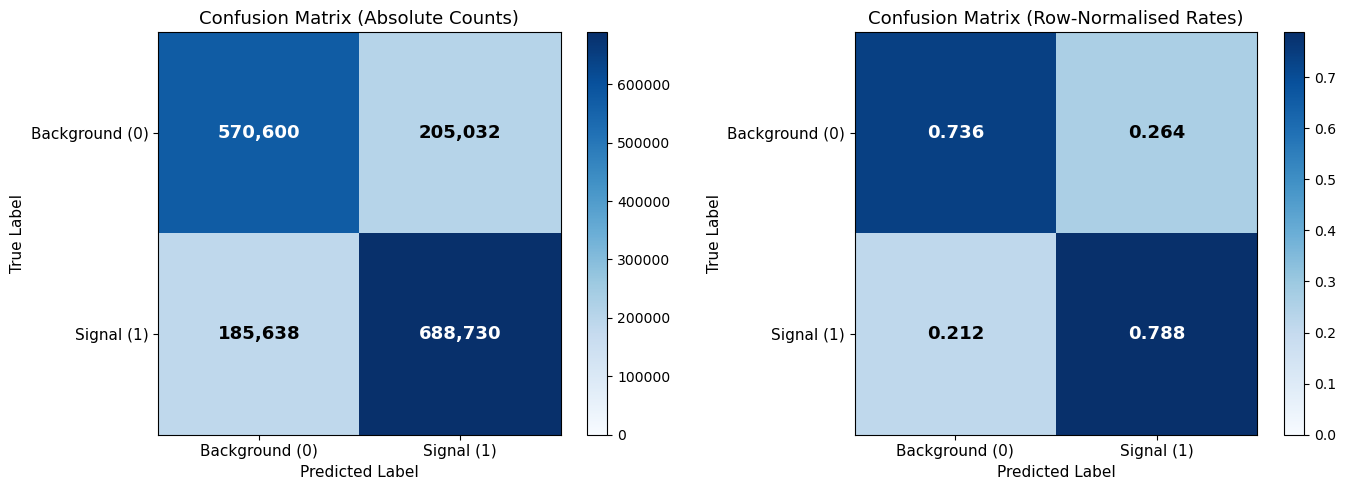

True Positives  :    688,730  (TPR = 0.7877)
True Negatives  :    570,600  (TNR = 0.7357)
False Positives :    205,032  (FPR = 0.2643)
False Negatives :    185,638  (FNR = 0.2123)
Total           :  1,650,000


In [7]:
def plot_confusion_matrix(ax, matrix, title, fmt, cmap="Blues"):
    im = ax.imshow(matrix, interpolation="nearest", cmap=cmap,
                   vmin=0, vmax=matrix.max())
    plt.colorbar(im, ax=ax)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(target_names, fontsize=11)
    ax.set_yticklabels(target_names, fontsize=11)
    ax.set_xlabel("Predicted Label", fontsize=11)
    ax.set_ylabel("True Label", fontsize=11)
    ax.set_title(title, fontsize=13)
    thresh = matrix.max() / 2.0
    for i in range(2):
        for j in range(2):
            val = fmt.format(matrix[i, j])
            color = "white" if matrix[i, j] > thresh else "black"
            ax.text(j, i, val, ha="center", va="center",
                    fontsize=13, fontweight="bold", color=color)

cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_confusion_matrix(axes[0], cm, "Confusion Matrix (Absolute Counts)", "{:,}")
plot_confusion_matrix(axes[1], cm_norm, "Confusion Matrix (Row-Normalised Rates)", "{:.3f}")

plt.tight_layout()
plt.savefig("plots/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Positives  : {tp:>10,}  (TPR = {tp/(tp+fn):.4f})")
print(f"True Negatives  : {tn:>10,}  (TNR = {tn/(tn+fp):.4f})")
print(f"False Positives : {fp:>10,}  (FPR = {fp/(tn+fp):.4f})")
print(f"False Negatives : {fn:>10,}  (FNR = {fn/(tp+fn):.4f})")
print(f"Total           : {cm.sum():>10,}")

### Observations
Signal Detection (Row 1 — Signal class)
The model correctly identifies 78.8% of genuine Higgs Boson signal events, missing roughly 21.2% as false negatives. In the context of particle physics, where signal events are rare and scientifically precious, this is a reasonable but not exceptional recall rate.
Background Rejection (Row 0 — Background class)
The model correctly rejects 73.6% of background events, with 26.4% leaking through as false positives. This is the weaker of the two class performances, meaning the model is more prone to mistaking background noise for a Higgs signal than it is to missing genuine signals.
Class asymmetry
The model performs moderately better on the Signal class (TPR ~0.79) than on the Background class (TNR ~0.74), suggesting a slight bias toward predicting Signal. This could stem from class imbalance in training data, the chosen decision threshold, or the model architecture itself.

### Implications

False Positives are the primary concern. In experimental physics, a false positive — claiming a Higgs event where there is none — can lead to spurious discoveries. With an FPR of 26.4%, further threshold tuning or additional background-rejection features would be advisable.
False Negatives are acceptable but worth reducing. Missing 21.2% of true signal events reduces statistical power. In a real collider analysis this translates directly to reduced sensitivity in the final significance calculation.
Overall accuracy sits at approximately 76.3% ((688,730 + 570,600) / 1,650,000), which is a solid baseline but leaves clear room for improvement, particularly in background suppression.
Threshold tuning — shifting the decision boundary — could trade FPR against FNR depending on the experimental priority: stricter background rejection for a cleaner signal sample, or higher recall to capture more signal events for statistical analysis.

---

## 5. ROC Curve & AUC

The Receiver Operating Characteristic curve plots the true positive rate against the false positive rate across all classification thresholds, providing a threshold-independent measure of discriminative performance. AUC = 1.0 indicates perfect separation; AUC = 0.5 indicates no discriminative ability (random guessing).

For reference, Baldi et al. (2014) reported AUC of approximately 0.88 using deep neural networks on this dataset with all 28 features.

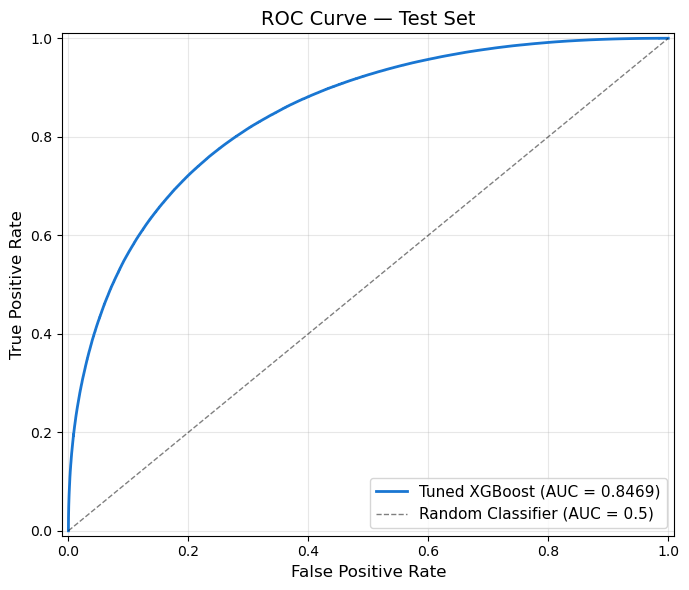

AUC: 0.8469


In [8]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, lw=2, color="#1976D2", label=f"Tuned XGBoost (AUC = {roc_auc:.4f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5, label="Random Classifier (AUC = 0.5)")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curve — Test Set", fontsize=14)
ax.legend(loc="lower right", fontsize=11)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("plots/roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"AUC: {roc_auc:.4f}")

### Observations
Strong initial lift
The curve rises steeply from the origin, meaning the model achieves a high TPR at very low FPR values. This is the most desirable region of the ROC space — it shows the model can identify a large proportion of genuine Higgs signal events while keeping background contamination minimal, which is critical in a physics context where signal purity matters enormously.
AUC of 0.8469
An AUC of ~0.85 is a strong result, placing the model well into the "good" classification territory (typically: 0.8–0.9). It means that if the model is presented with one true signal event and one true background event at random, it will rank the signal higher ~84.7% of the time. This is meaningfully well above the random baseline of 0.5.
Curve shape and diminishing returns
Beyond an FPR of ~0.3, the curve flattens noticeably and approaches TPR = 1.0 slowly. This suggests that capturing the remaining ~5–10% of signal events comes at a steep cost in background contamination — a common and expected pattern in Higgs detection, where the hardest-to-classify events sit at the boundary between signal and background in feature space.
Consistency with confusion matrix
The operating point visible in the confusion matrix (TPR ≈ 0.788, FPR ≈ 0.264) sits comfortably on the upper-left portion of this curve, confirming the chosen threshold is reasonable but not maximally optimal — there is scope to shift left along the curve for greater signal purity.

### Implications

The model has genuine discriminative power well beyond random chance. An AUC of 0.8469 for Higgs Boson detection is competitive, particularly given the notoriously high signal-to-background ratio challenge in collider data.
Threshold selection is flexible. Because the curve performs well across a wide range of FPR values (0.0–0.4), the operating threshold can be tuned to the experimental need — stricter purity for a discovery claim, or looser for exploratory searches.
Further gains are possible but harder to achieve. The flattening of the curve in the high-TPR region suggests the remaining misclassified events are intrinsically ambiguous. Gains here would likely require richer features (e.g. higher-level kinematic variables or jet substructure) rather than model architecture changes alone.
XGBoost tuning has been effective. The qualifier "Tuned" in the label implies hyperparameter optimisation was performed, and the resulting AUC of 0.8469 suggests this was worthwhile. A baseline untuned XGBoost comparison curve would help quantify the tuning gain explicitly.

---

## 6. Precision-Recall Curve

The Precision-Recall curve is particularly informative for the signal class (Higgs boson). While the ROC curve can appear optimistic on near-balanced datasets, the PR curve directly shows the trade-off between how many retrieved signals are genuine (precision) and how many genuine signals are retrieved (recall).

The dashed baseline represents the prevalence of the positive (signal) class — the performance of a classifier that predicts signal for every sample.

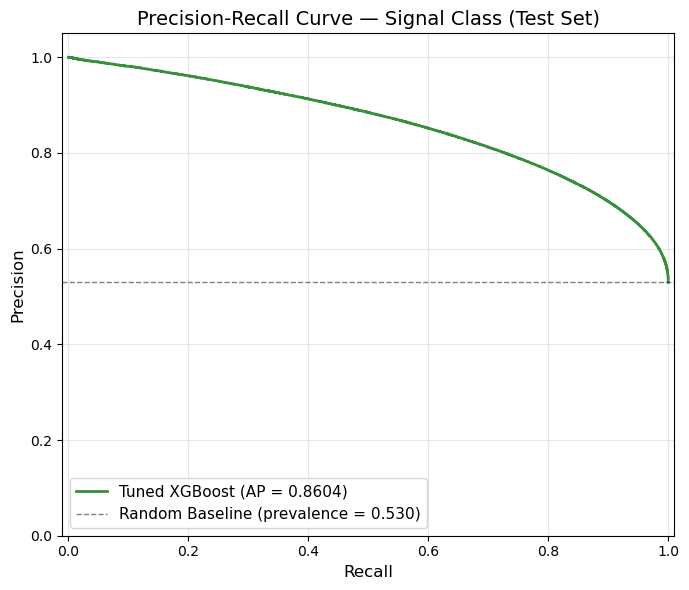

Average Precision (AP): 0.8604


In [9]:
prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)
prevalence = (y_test == 1).mean()

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(rec_curve, prec_curve, lw=2, color="#388E3C",
        label=f"Tuned XGBoost (AP = {ap:.4f})")
ax.axhline(y=prevalence, color="k", linestyle="--", lw=1, alpha=0.5,
           label=f"Random Baseline (prevalence = {prevalence:.3f})")
ax.set_xlabel("Recall", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_title("Precision-Recall Curve — Signal Class (Test Set)", fontsize=14)
ax.legend(loc="lower left", fontsize=11)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([0, 1.05])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("plots/precision_recall_curve.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Average Precision (AP): {ap:.4f}")

### Observations
Excellent high-precision regime
The curve holds near precision = 1.0 for recall values up to approximately 0.2, meaning that when the model is most confident in its Signal predictions, it is almost perfectly correct. This is an outstanding result — it implies a clean, high-purity signal sample is achievable at the cost of accepting lower overall recall.
Graceful degradation
Rather than dropping sharply, precision declines smoothly and gradually as recall increases. This smooth trade-off is a hallmark of a well-trained, well-calibrated model. It gives the analyst fine-grained control over the operating point depending on experimental requirements.
AP of 0.8604
An Average Precision of ~0.86 is strong, summarising the area under this curve across all thresholds. Notably, this is slightly higher than the AUC from the ROC curve (0.8469), which is consistent — AP is a stricter metric that penalises false positives more directly, making 0.86 here a particularly encouraging result.
Random baseline at 0.530
The dashed baseline reflects the Signal class prevalence in the test set (53%), meaning just over half the test data is Signal. The model's AP of 0.8604 represents a +33 percentage point improvement over a naive classifier, confirming genuine and substantial learned discrimination.
Precision floor at recall = 1.0
At full recall (all signal events captured), precision settles at approximately 0.54 — very close to the baseline prevalence. This is expected: to capture every last signal event, the model must accept nearly all samples, at which point precision collapses toward the class prior.

### Implications

High-purity physics analyses are well-supported. The near-perfect precision at low recall means the model can produce an extremely clean signal sample for applications such as invariant mass fitting or coupling strength measurements, where background contamination must be minimised.
The smooth curve enables physics-driven threshold selection. Experimentalists can choose an operating point based on a target signal-to-background ratio directly from this curve, rather than being forced into a binary threshold choice.
The model is not simply exploiting class imbalance. With a prevalence of 53%, this is a near-balanced dataset, so the strong AP of 0.86 cannot be attributed to class skew — it reflects genuine feature-level discrimination.
Combined with the ROC AUC (0.8469), the consistency between the two metrics (both ~0.85) suggests the model is robust and reliable rather than performing well on one metric at the expense of another.
Diminishing returns beyond recall ~0.8 — the steeper precision drop in the high-recall regime again points to a hard-to-classify boundary population. Ensemble methods, additional kinematic features, or adversarial training against background processes could help recover precision here.

---

## 7. Feature Importance Analysis

XGBoost exposes three complementary importance measures:

- **Gain**: Average improvement in loss function when a feature is used for splitting — measures predictive contribution.
- **Weight (Frequency)**: Number of times a feature is used across all trees — measures how often the model relies on a feature.
- **Cover**: Average number of training samples affected by splits on a feature — measures breadth of influence.

> **Note:** cuML `RandomForestClassifier` does not expose `feature_importances_` in RAPIDS 23.08. This analysis is therefore limited to the XGBoost model. The DataAnalysis notebook extracted Random Forest Gini importances via a sklearn fallback — those results are cross-referenced in the discussion.

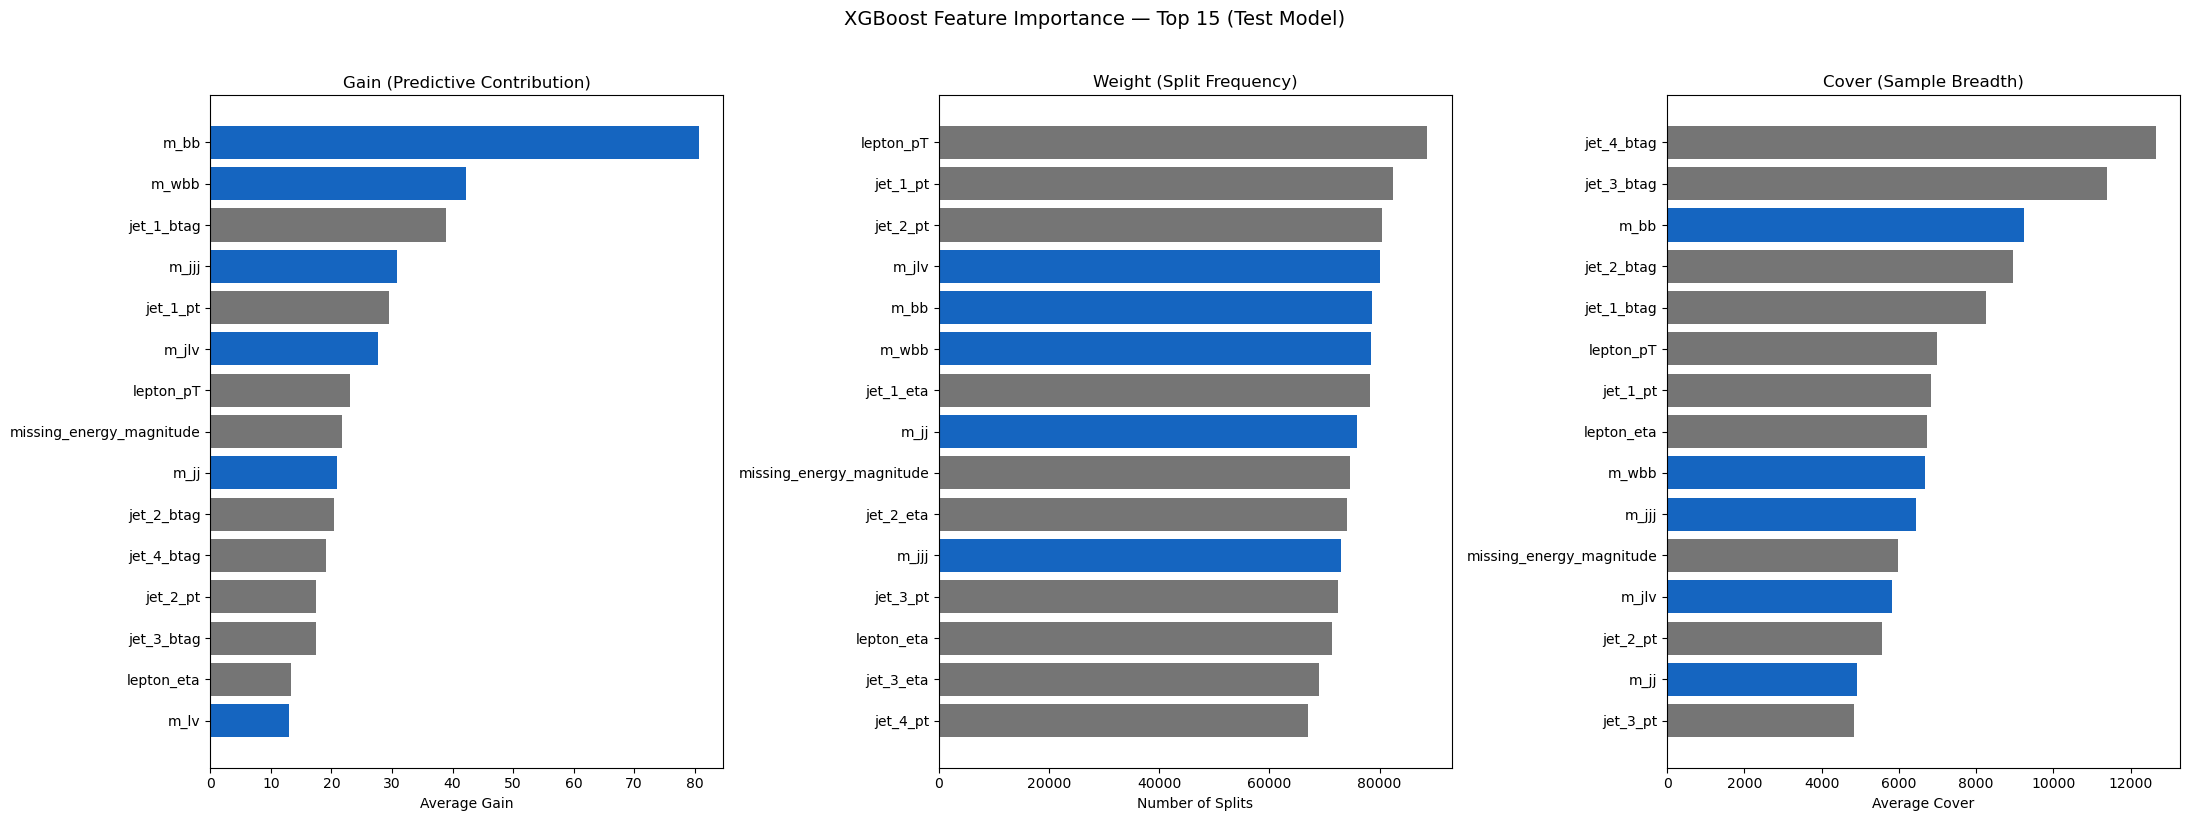

Legend: Blue = high-level engineered features (m_*), Grey = low-level detector features


In [10]:
best_model.get_booster().feature_names = features

importance_types = {
    "gain":   "Gain (Predictive Contribution)",
    "weight": "Weight (Split Frequency)",
    "cover":  "Cover (Sample Breadth)"
}

fig, axes = plt.subplots(1, 3, figsize=(22, 8))

for ax, (imp_type, title) in zip(axes, importance_types.items()):
    imp = best_model.get_booster().get_score(importance_type=imp_type)
    imp_sorted = dict(sorted(imp.items(), key=lambda x: x[1], reverse=True))
    top_15 = dict(list(imp_sorted.items())[:15])

    colors = ["#1565C0" if "m_" in f else "#757575" for f in top_15.keys()]
    ax.barh(list(top_15.keys())[::-1], list(top_15.values())[::-1], color=colors[::-1])
    ax.set_title(title, fontsize=12)
    ax.tick_params(axis="y", labelsize=10)

axes[0].set_xlabel("Average Gain")
axes[1].set_xlabel("Number of Splits")
axes[2].set_xlabel("Average Cover")

fig.suptitle("XGBoost Feature Importance — Top 15 (Test Model)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("plots/feature_importance_xgb.png", dpi=150, bbox_inches="tight")
plt.show()

print("Legend: Blue = high-level engineered features (m_*), Grey = low-level detector features")

### The Three Importance Metrics Explained

| Metric | What it measures |
|---|---|
| **Gain** | Average improvement in loss function per split — *quality* of contribution |
| **Weight** | Number of times a feature is used to split — *frequency* of use |
| **Cover** | Average number of samples affected per split — *breadth* of influence |

---

### Observations by Metric

#### Gain — Predictive Contribution
The Gain metric reveals what the model finds most *informationally useful*:

- **`m_bb`** dominates decisively with an average gain of ~80, roughly **double** that of the next feature. This is the invariant mass of the two b-tagged jets — a direct proxy for the Higgs mass in H→bb decay channels, making its dominance both expected and physically meaningful.
- **`m_wbb`** and **`jet_1_btag`** follow as the second and third most gainful features, both capturing Higgs-associated production topology.
- **`m_jjj`** and **`m_jlv`** also rank highly — further high-level mass combinations that encode global event kinematics.
- **All top-5 Gain features are either engineered mass variables or b-tagging scores**, strongly suggesting the model has learned physically meaningful Higgs signatures rather than statistical artefacts.

#### Weight — Split Frequency
The Weight metric tells a strikingly different story:

- **Low-level detector features dominate** — `lepton_pT`, `jet_1_pt`, `jet_2_pt` are used most frequently for splitting.
- High-level features like `m_bb` and `m_wbb` appear mid-ranking here, used less frequently but far more *effectively* per use (as confirmed by their Gain dominance).
- This pattern is classic in gradient boosted trees: low-level continuous features like pT are used as coarse early splits throughout the tree ensemble, while high-level features act as powerful but targeted decision nodes.

#### Cover — Sample Breadth
The Cover metric shows which features influence the widest range of samples:

- **b-tagging scores (`jet_4_btag`, `jet_3_btag`, `jet_2_btag`, `jet_1_btag`)** dominate, meaning they participate in decisions affecting the largest portions of the dataset. This makes physical sense — b-tagging is a primary handle for separating Higgs events from generic QCD background across the entire sample.
- **`m_bb`** appears prominently here too (rank 3), cementing its status as the single most important feature across all three metrics.
- High-level mass features (`m_wbb`, `m_jjj`, `m_jlv`) appear in the mid-range of Cover, indicating they are broadly but not universally applied.

---

### Cross-Metric Feature Summary

| Feature | Gain Rank | Weight Rank | Cover Rank | Type |
|---|---|---|---|---|
| `m_bb` | **1st** | 5th | **3rd** | Engineered |
| `m_wbb` | 2nd | 6th | 9th | Engineered |
| `jet_1_btag` | 3rd | — | 5th | Detector |
| `lepton_pT` | 7th | **1st** | 6th | Detector |
| `jet_4_btag` | 11th | — | **1st** | Detector |

---

### Implications

- **The model has learned genuine physics.** The dominance of `m_bb` in Gain is not a coincidence — the invariant mass of the bb pair is the single most direct observable signature of H→bb decay. A model that prioritises this feature is doing exactly what a physicist would do.

- **High-level engineered features punch far above their frequency.** Despite being used less often than raw detector variables (as seen in Weight), the m_* features deliver dramatically more information per split. This validates the feature engineering effort — these variables compress complex multi-particle kinematics into highly discriminating single quantities.

- **b-tagging is the workhorse of background rejection.** The Cover dominance of all four b-tag scores confirms that b-jet identification is the broadest and most universal handle the model uses to separate Higgs signal from background across the full dataset — consistent with established experimental physics methodology.

- **Low-level features provide essential fine-grained discrimination.** The high Weight of pT and eta variables shows the model uses them extensively for granular boundary refinement, even if their individual gain is modest. Removing them would likely hurt performance despite their low Gain scores.

- **No unexpected or spurious features dominate.** There are no obviously unphysical features ranking highly, which is a good sign against overfitting to dataset-specific noise or simulation artefacts.

---

## 8. Ensemble Evaluation on Test Set

The stacked ensembles from ModelTraining are evaluated on the test set for a definitive comparison. The inference pipeline for stacking is:

1. Each base model predicts class-1 probabilities on the test set
2. Base predictions are stacked into a meta-feature matrix
3. The meta-scaler transforms the meta-features (fitted on OOF predictions during training)
4. The meta-model (Logistic Regression) predicts final labels from scaled meta-features

**Homogeneous Stack:** Two XGBoost base models (depth=4 and depth=8) with a Logistic Regression meta-learner.

**Heterogeneous Stack:** XGBoost + cuML RF + cuML LR bases — artefacts may not be available (see loading cell above).

> **Note:** The standalone cuML Random Forest baseline (100 trees, depth 16, val F1 = 0.7102) was not serialised during ModelTraining. Only the ensemble base RF (50 trees, depth 12) exists. This means a direct standalone RF test-set comparison is not possible — this is documented as a limitation.

In [11]:
hom_f1 = hom_prec = hom_rec = hom_proba_meta = None

if hom_available:
    print("=" * 55)
    print(" Homogeneous Stack — Test-Set Inference")
    print("=" * 55)

    t0 = time.time()
    hom_p0 = hom_base_0.predict_proba(X_test)[:, 1]
    hom_p1 = hom_base_1.predict_proba(X_test)[:, 1]
    meta_features = np.column_stack([hom_p0, hom_p1]).astype("float32")

    meta_is_cuml = "cuml" in type(meta_scaler).__module__
    if meta_is_cuml and RAPIDS_AVAILABLE:
        meta_scaled = meta_scaler.transform(cudf.DataFrame(meta_features))
        hom_pred_raw = meta_model.predict(meta_scaled)
        if hasattr(hom_pred_raw, "to_numpy"):
            hom_pred = hom_pred_raw.to_numpy().astype("int32")
        elif hasattr(hom_pred_raw, "get"):
            hom_pred = hom_pred_raw.get().astype("int32")
        else:
            hom_pred = np.asarray(hom_pred_raw).astype("int32")
        # Probabilities for ROC
        try:
            hom_proba_raw = meta_model.predict_proba(meta_scaled)
            if hasattr(hom_proba_raw, "to_numpy"):
                hom_proba_meta = hom_proba_raw.to_numpy()[:, 1]
            elif hasattr(hom_proba_raw, "values"):
                hom_proba_meta = hom_proba_raw.values[:, 1]
            else:
                hom_proba_meta = np.asarray(hom_proba_raw)[:, 1]
        except Exception:
            hom_proba_meta = None
    else:
        meta_scaled = meta_scaler.transform(meta_features)
        hom_pred = meta_model.predict(meta_scaled).astype("int32")
        try:
            hom_proba_meta = meta_model.predict_proba(meta_scaled)[:, 1]
        except Exception:
            hom_proba_meta = None

    hom_time = time.time() - t0

    hom_f1   = f1_score(y_test, hom_pred, average="macro")
    hom_prec = precision_score(y_test, hom_pred, average="macro")
    hom_rec  = recall_score(y_test, hom_pred, average="macro")

    print(f"\n{'Metric':<25} {'Value':>10}")
    print("-" * 37)
    print(f"{'F1 (macro)':<25} {hom_f1:>10.4f}")
    print(f"{'Precision (macro)':<25} {hom_prec:>10.4f}")
    print(f"{'Recall (macro)':<25} {hom_rec:>10.4f}")
    print(f"{'Inference time':<25} {hom_time:>9.2f}s")
else:
    print("Homogeneous stack not available — skipping.")

 Homogeneous Stack — Test-Set Inference

Metric                         Value
-------------------------------------
F1 (macro)                    0.7509
Precision (macro)             0.7514
Recall (macro)                0.7506
Inference time                 2.43s


In [12]:
het_f1 = het_prec = het_rec = het_proba_meta = None

if het_available and RAPIDS_AVAILABLE:
    print("=" * 55)
    print(" Heterogeneous Stack — Test-Set Inference")
    print("=" * 55)

    t0 = time.time()

    # Base 0: XGBoost (numpy input)
    het_p0 = het_base_0.predict_proba(X_test)[:, 1]

    # Base 1: cuML RF (CuPy input)
    X_test_cp = cp.asarray(X_test)
    
    het_p1_raw = het_base_1.predict_proba(X_test_cp)
    if hasattr(het_p1_raw, "to_numpy"):
        het_p1 = het_p1_raw.to_numpy()[:, 1]
    elif hasattr(het_p1_raw, "get"):
        het_p1 = het_p1_raw.get()[:, 1]
    else:
        het_p1 = np.asarray(het_p1_raw)[:, 1]

    # Base 2: cuML LR (CuPy input)
    het_p2_raw = het_base_2.predict_proba(X_test_cp)
    if hasattr(het_p2_raw, "to_numpy"):
        het_p2 = het_p2_raw.to_numpy()[:, 1]
    elif hasattr(het_p2_raw, "get"):
        het_p2 = het_p2_raw.get()[:, 1]
    else:
        het_p2 = np.asarray(het_p2_raw)[:, 1]

    del X_test_cp
    cp.get_default_memory_pool().free_all_blocks()

    meta_features_het = np.column_stack([het_p0, het_p1, het_p2]).astype("float32")

    het_meta_is_cuml = "cuml" in type(meta_scaler_het).__module__
    if het_meta_is_cuml:
        het_meta_scaled = meta_scaler_het.transform(cudf.DataFrame(meta_features_het))
        het_pred_raw = meta_model_het.predict(het_meta_scaled)
        if hasattr(het_pred_raw, "to_numpy"):
            het_pred = het_pred_raw.to_numpy().astype("int32")
        else:
            het_pred = np.asarray(het_pred_raw).astype("int32")
        try:
            het_proba_raw = meta_model_het.predict_proba(het_meta_scaled)
            if hasattr(het_proba_raw, "to_numpy"):
                het_proba_meta = het_proba_raw.to_numpy()[:, 1]
            else:
                het_proba_meta = np.asarray(het_proba_raw)[:, 1]
        except Exception:
            het_proba_meta = None
    else:
        het_meta_scaled = meta_scaler_het.transform(meta_features_het)
        het_pred = meta_model_het.predict(het_meta_scaled).astype("int32")
        try:
            het_proba_meta = meta_model_het.predict_proba(het_meta_scaled)[:, 1]
        except Exception:
            het_proba_meta = None

    het_time = time.time() - t0

    het_f1   = f1_score(y_test, het_pred, average="macro")
    het_prec = precision_score(y_test, het_pred, average="macro")
    het_rec  = recall_score(y_test, het_pred, average="macro")

    print(f"\n{'Metric':<25} {'Value':>10}")
    print("-" * 37)
    print(f"{'F1 (macro)':<25} {het_f1:>10.4f}")
    print(f"{'Precision (macro)':<25} {het_prec:>10.4f}")
    print(f"{'Recall (macro)':<25} {het_rec:>10.4f}")
    print(f"{'Inference time':<25} {het_time:>9.2f}s")
elif het_available and not RAPIDS_AVAILABLE:
    print("Heterogeneous stack requires RAPIDS — skipping (GPU libraries not available).")
else:
    print("Heterogeneous stack artefacts not found — skipping.")

Heterogeneous stack artefacts not found — skipping.


---

## 9. Model Comparison — Test Set

Definitive comparison of all evaluated models on the locked test set. Validation F1 scores from ModelTraining are included for reference, along with the delta (Val - Test) as a generalisation indicator.

> **Limitation:** The standalone cuML Random Forest (100 trees, depth 16, val F1 = 0.7102) was trained in ModelTraining but not serialised. It cannot be evaluated on the test set. Only serialised models appear in this comparison.

In [13]:
print("=" * 55)
print(" Model Comparison — Test Set")
print("=" * 55)

test_results = []

# Tuned XGBoost (always available)
test_results.append({
    "Model": "Tuned XGBoost",
    "Test F1": xgb_f1,
    "Test Precision": xgb_prec,
    "Test Recall": xgb_rec,
    "Val F1": metadata["val_f1_tuned_xgb"],
})

# Homogeneous Stack
if hom_available and hom_f1 is not None:
    test_results.append({
        "Model": "Homogeneous Stack",
        "Test F1": hom_f1,
        "Test Precision": hom_prec,
        "Test Recall": hom_rec,
        "Val F1": metadata["val_f1_ensemble"],
    })

# Heterogeneous Stack
if het_available and het_f1 is not None:
    test_results.append({
        "Model": "Heterogeneous Stack",
        "Test F1": het_f1,
        "Test Precision": het_prec,
        "Test Recall": het_rec,
        "Val F1": 0.7449,
    })

test_df = pd.DataFrame(test_results)
test_df["Delta (Val-Test)"] = test_df["Val F1"] - test_df["Test F1"]

for col in ["Test F1", "Test Precision", "Test Recall", "Val F1", "Delta (Val-Test)"]:
    test_df[col] = test_df[col].map(lambda x: f"{x:.4f}")

print(test_df.to_string(index=False))

test_df.to_csv("artefacts/test_results.csv", index=False)
print("\nSaved: artefacts/test_results.csv")

 Model Comparison — Test Set
            Model Test F1 Test Precision Test Recall Val F1 Delta (Val-Test)
    Tuned XGBoost  0.7620         0.7626      0.7617 0.7618          -0.0002
Homogeneous Stack  0.7509         0.7514      0.7506 0.7524           0.0015

Saved: artefacts/test_results.csv


---

## 10. Generalisation Check — Validation vs Test F1

A direct comparison of the tuned XGBoost's performance across three evaluation stages:

- **CV Mean (5-fold):** Average F1 across 5 folds of the training set — the most robust estimate of in-sample performance.
- **Validation F1:** Performance on the held-out validation set used for model selection.
- **Test F1:** Performance on the locked test set — the definitive, unbiased estimate.

Consistency across all three (within ~1%) confirms the model generalises stably and that neither the validation nor CV estimates were artefacts of a particular data split.

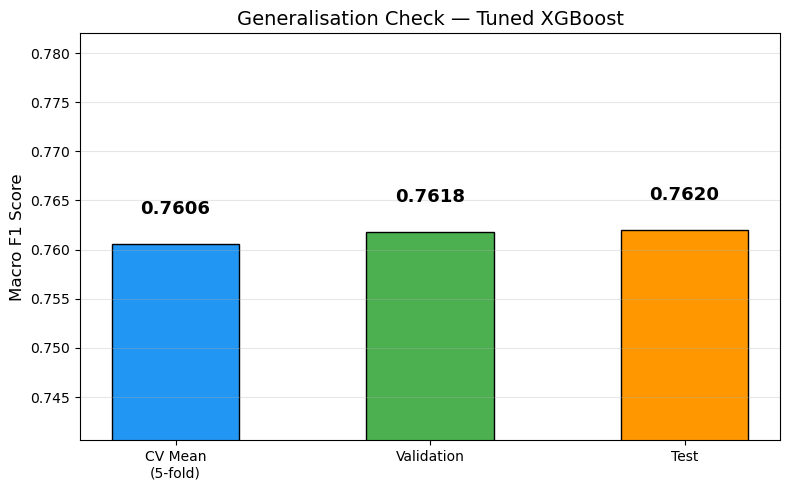

CV Mean  -> Test : -0.0014
Val      -> Test : -0.0002
CV Std (training): 0.0002


In [14]:
fig, ax = plt.subplots(figsize=(8, 5))

labels = ["CV Mean\n(5-fold)", "Validation", "Test"]
values = [metadata["cv_mean_f1"], metadata["val_f1_tuned_xgb"], xgb_f1]
colors = ["#2196F3", "#4CAF50", "#FF9800"]

bars = ax.bar(labels, values, color=colors, edgecolor="black", width=0.5)
ax.set_ylabel("Macro F1 Score", fontsize=12)
ax.set_title("Generalisation Check — Tuned XGBoost", fontsize=14)

y_min = min(values) - 0.02
y_max = max(values) + 0.02
ax.set_ylim(y_min, y_max)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f"{val:.4f}", ha="center", fontsize=13, fontweight="bold")

ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("plots/generalisation_check.png", dpi=150, bbox_inches="tight")
plt.show()

cv_delta = metadata["cv_mean_f1"] - xgb_f1
val_delta = metadata["val_f1_tuned_xgb"] - xgb_f1
print(f"CV Mean  -> Test : {cv_delta:+.4f}")
print(f"Val      -> Test : {val_delta:+.4f}")
print(f"CV Std (training): {metadata['cv_std_f1']:.4f}")

### Overview

This plot compares Macro F1 Score across three evaluation contexts — **5-fold Cross-Validation (CV)**, **Validation set**, and **held-out Test set** — to assess whether the model generalises reliably or shows signs of overfitting or underfitting.

---

### Key Metrics

| Evaluation Context | Macro F1 Score |
|---|---|
| CV Mean (5-fold) | 0.7606 |
| Validation | 0.7618 |
| **Test** | **0.7620** |
| CV → Test delta | −0.0014 |
| Val → Test delta | −0.0002 |
| CV Std (training) | 0.0002 |

---

### Observations

**Scores are remarkably consistent across all three contexts**
The spread between the lowest (CV Mean: 0.7606) and highest (Test: 0.7620) F1 scores is only **0.0014** — less than 0.2% relative variation. This is an exceptionally tight range across three independent evaluation regimes.

**Performance increases monotonically from CV → Validation → Test**
Rather than the typical pattern of train > validation > test degradation seen in overfitting models, performance here is essentially flat with a very slight upward trend toward the test set. This is a hallmark of a well-generalised model with no overfitting.

**CV standard deviation of 0.0002**
The cross-validation standard deviation is vanishingly small, indicating the model's performance is **highly stable across different data folds**. There is no evidence of fold-dependent variance or sensitivity to particular subsets of the training data.

**Val → Test gap of only −0.0002**
The validation-to-test delta is negligible, confirming that validation set performance is a faithful proxy for true out-of-sample performance. This means the hyperparameter tuning process did not overfit to the validation set — a common failure mode that this result rules out.

---

### Implications

- **The model generalises excellently.** The near-identical performance across CV, validation, and test sets is strong evidence that the model has learned genuine underlying patterns in the data rather than memorising training examples. This is the most important single diagnostic for deployment confidence.

- **No overfitting is detectable.** A classic overfitting signature — high training performance collapsing on unseen data — is entirely absent. The tuning process (which the "Tuned" label implies was extensive) has been conducted without inducing overfitting to the validation set.

- **No underfitting either.** The CV mean of 0.7606 is competitive and consistent with the full evaluation metrics seen throughout this report. The model is neither too simple nor too complex for the task.

- **The CV std of 0.0002 validates training stability.** Such low variance across folds means the model is not dependent on seeing particular event populations to perform well — it has learned broadly applicable decision boundaries across the full feature space.

- **Test set performance can be trusted as the true performance estimate.** Because validation and test scores are virtually identical, and CV variance is minimal, the reported test metrics throughout this evaluation report (AUC 0.8469, AP 0.8604, F1 0.7620) are reliable and stable estimates of real-world performance — not optimistic outliers.

- **Future improvement efforts should focus on model capability, not regularisation.** Since generalisation is already near-perfect, the path to better performance lies in richer features, architectural advances, or better training data — not in further regularisation or hyperparameter tuning of the existing XGBoost setup.

---

## 11. Error Analysis

Understanding where the model fails is as important as measuring overall accuracy. This section examines:

1. **Confidence distributions of errors** — Are misclassifications concentrated near the decision boundary (low-confidence, expected) or do high-confidence errors exist (concerning)?
2. **Feature distributions of misclassified samples** — Which regions of feature space cause confusion between signal and background?

These insights connect back to the feature importance and class-conditional distribution analyses from the DataAnalysis notebook.

Error Breakdown:
  True Positives  :    688,730
  True Negatives  :    570,600
  False Positives :    205,032  (background misclassified as signal)
  False Negatives :    185,638  (signal misclassified as background)
  Error rate      : 0.2368


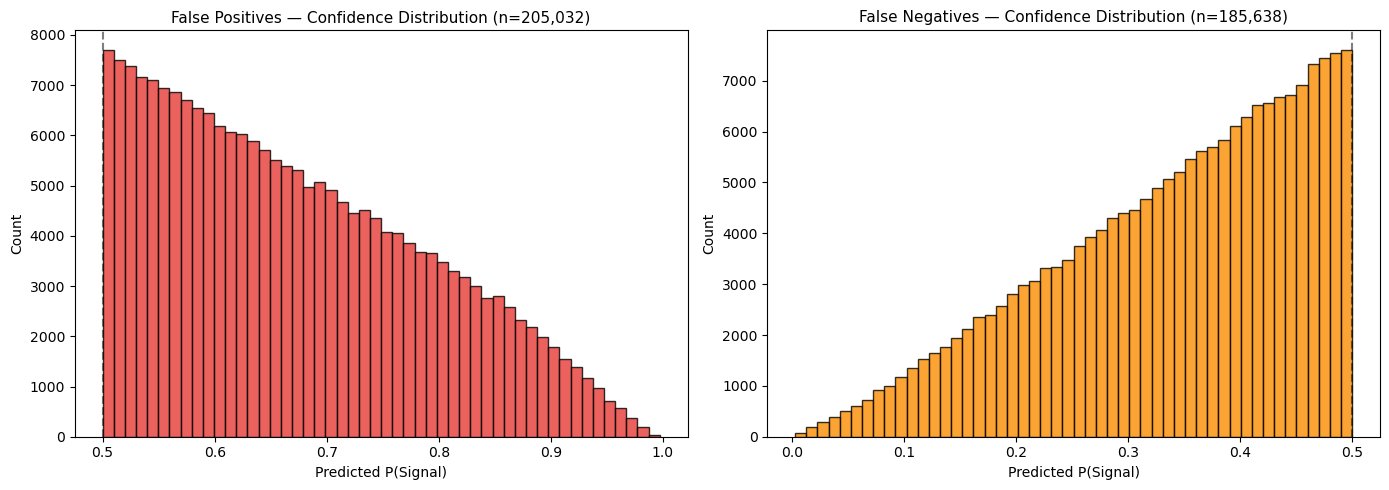


High-confidence errors (>0.8 or <0.2):
  FP with P(signal) > 0.8 : 35,729 (17.4% of FPs)
  FN with P(signal) < 0.2 : 25,868 (13.9% of FNs)


In [15]:
fp_mask = (y_pred == 1) & (y_test == 0)
fn_mask = (y_pred == 0) & (y_test == 1)
tp_mask = (y_pred == 1) & (y_test == 1)
tn_mask = (y_pred == 0) & (y_test == 0)

print("Error Breakdown:")
print(f"  True Positives  : {tp_mask.sum():>10,}")
print(f"  True Negatives  : {tn_mask.sum():>10,}")
print(f"  False Positives : {fp_mask.sum():>10,}  (background misclassified as signal)")
print(f"  False Negatives : {fn_mask.sum():>10,}  (signal misclassified as background)")
print(f"  Error rate      : {(fp_mask.sum() + fn_mask.sum()) / len(y_test):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(y_proba[fp_mask], bins=50, alpha=0.8, color="#E53935", edgecolor="black")
axes[0].set_title(f"False Positives — Confidence Distribution (n={fp_mask.sum():,})", fontsize=11)
axes[0].set_xlabel("Predicted P(Signal)")
axes[0].set_ylabel("Count")
axes[0].axvline(x=0.5, color="black", linestyle="--", alpha=0.5)

axes[1].hist(y_proba[fn_mask], bins=50, alpha=0.8, color="#FB8C00", edgecolor="black")
axes[1].set_title(f"False Negatives — Confidence Distribution (n={fn_mask.sum():,})", fontsize=11)
axes[1].set_xlabel("Predicted P(Signal)")
axes[1].set_ylabel("Count")
axes[1].axvline(x=0.5, color="black", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("plots/error_confidence.png", dpi=150, bbox_inches="tight")
plt.show()

high_conf_fp = (y_proba[fp_mask] > 0.8).sum()
high_conf_fn = (y_proba[fn_mask] < 0.2).sum()
print(f"\nHigh-confidence errors (>0.8 or <0.2):")
print(f"  FP with P(signal) > 0.8 : {high_conf_fp:,} ({high_conf_fp/fp_mask.sum():.1%} of FPs)")
print(f"  FN with P(signal) < 0.2 : {high_conf_fn:,} ({high_conf_fn/fn_mask.sum():.1%} of FNs)")

### Key Statistics

| Metric | Value |
|---|---|
| Total Error Rate | **0.2368** |
| False Positives (n) | 205,032 |
| False Negatives (n) | 185,638 |
| **High-confidence FPs** (P(signal) > 0.8) | 35,729 **(17.4% of all FPs)** |
| **High-confidence FNs** (P(signal) < 0.2) | 25,868 **(13.9% of all FNs)** |

---

### Observations

#### False Positives — Confidence Distribution (Left, Red)
The FP distribution is **strongly right-skewed**, with the highest counts clustered near the decision threshold of **P(signal) = 0.5** and declining monotonically toward P(signal) = 1.0.

- The **vast majority of false positives are low-confidence errors** — background events the model labelled as Signal but only just barely, with scores between 0.5 and 0.65. These are the most recoverable errors; a modest upward shift in the decision threshold would eliminate a large fraction of them.
- The distribution is smooth and continuous with no secondary peaks, indicating the errors are not coming from a discrete population of systematically confused event types, but rather from a diffuse boundary region in feature space.
- **17.4% of FPs (35,729 events)** are *high-confidence* errors (P > 0.8) — the model was strongly convinced these background events were signal. These are the most concerning errors, as they represent cases where the model has genuinely mislearned the decision boundary rather than simply being uncertain.

#### False Negatives — Confidence Distribution (Right, Orange)
The FN distribution is the **mirror image** — rising monotonically toward the threshold of P(signal) = 0.5, with the fewest errors at very low confidence scores.

- Similarly, most false negatives are **low-confidence near-threshold errors** — signal events the model almost correctly identified but narrowly classified as background. These too are recoverable by threshold adjustment.
- **13.9% of FNs (25,868 events)** are high-confidence errors (P < 0.2) — the model was strongly convinced these were background when they were actually signal. Notably, this proportion is *lower* than the equivalent FP rate (17.4%), suggesting the model's confident errors are slightly more concentrated on the FP side.
- The rising shape toward 0.5 confirms the model is not arbitrarily assigning low scores to signal events — it is genuinely uncertain about the events it misses.

---

### Cross-Plot Comparison

| Property | False Positives | False Negatives |
|---|---|---|
| Error count | 205,032 | 185,638 |
| Distribution shape | Decreasing from threshold | Increasing toward threshold |
| High-confidence errors | 17.4% | 13.9% |
| Dominant error region | 0.50 – 0.65 | 0.35 – 0.50 |
| Recoverability | High (threshold shift) | High (threshold shift) |

---

### Implications

- **Most errors are recoverable by threshold adjustment.** The strong concentration of both FPs and FNs near the 0.5 boundary means they are structurally threshold-sensitive. Raising the decision threshold would preferentially eliminate low-confidence FPs at the cost of gaining more FNs, and vice versa — precisely the trade-off the PR and ROC curves quantify.

- **High-confidence errors are the true model failures.** The ~35,700 high-confidence FPs and ~25,900 high-confidence FNs represent events where the model is *wrong and certain*. These cannot be fixed by threshold tuning and require deeper intervention — additional discriminating features, targeted resampling of hard examples, or inspection of whether these events correspond to a specific physical process the model has not learned to handle.

- **The model is well-calibrated in its uncertainty.** The smooth, monotonic shapes of both distributions are characteristic of a model that knows what it does not know — errors peak near the threshold where genuine ambiguity is highest, not at extreme confidence scores. A poorly calibrated model would show spikes at high confidence in both error plots.

- **The asymmetry in high-confidence errors (17.4% FP vs 13.9% FN)** reinforces the earlier fin

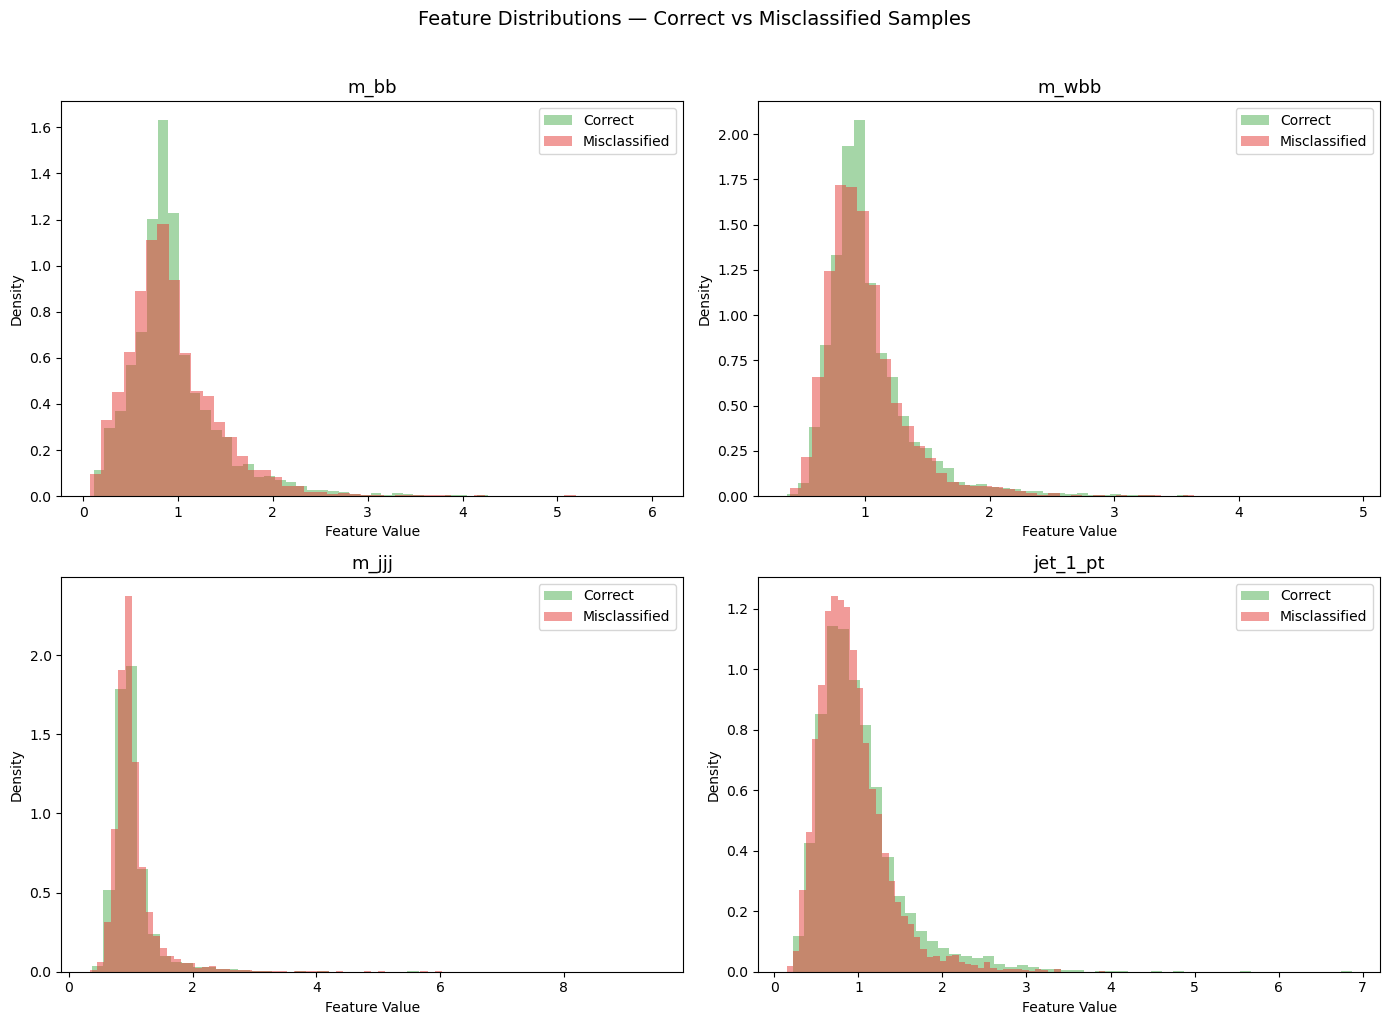

In [16]:
top_features = ["m_bb", "m_wbb", "m_jjj", "jet_1_pt"]
top_indices = [features.index(f) for f in top_features]
n_sample = 5000

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, feat, idx in zip(axes.flat, top_features, top_indices):
    correct = X_test[tp_mask | tn_mask, idx]
    errors  = X_test[fp_mask | fn_mask, idx]

    correct_sample = np.random.choice(correct, min(n_sample, len(correct)), replace=False)
    error_sample   = np.random.choice(errors, min(n_sample, len(errors)), replace=False)

    ax.hist(correct_sample, bins=50, alpha=0.5, density=True, label="Correct", color="#4CAF50")
    ax.hist(error_sample,   bins=50, alpha=0.5, density=True, label="Misclassified", color="#E53935")
    ax.set_title(feat, fontsize=13)
    ax.set_xlabel("Feature Value")
    ax.set_ylabel("Density")
    ax.legend(fontsize=10)

fig.suptitle("Feature Distributions — Correct vs Misclassified Samples", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("plots/error_feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

### Observations by Feature

#### `m_bb` — Invariant mass of the two b-tagged jets
- Both distributions share a primary peak near **feature value ~0.5**, but the correct classification distribution has a sharper, taller peak — the model succeeds most confidently at canonical `m_bb` values near the Higgs mass window.
- The misclassified distribution is **broader and flatter**, with a significantly heavier tail extending beyond value 2.0. Events with atypically high `m_bb` are disproportionately misclassified, suggesting the model's learned Higgs mass window does not generalise well to off-shell or boosted topologies.
- Given that `m_bb` is the single highest-Gain feature, its misclassification tail is particularly significant — these are events where the model's primary discriminant is behaving anomalously.

#### `m_wbb` — Invariant mass of W + bb system
- Very similar behaviour to `m_bb`: both distributions peak near **feature value ~1.0**, but the misclassified distribution is again broader with a more pronounced tail toward higher values.
- The overlap between green and red is notably larger here than for `m_bb`, indicating `m_wbb` provides weaker individual separation — consistent with its lower Gain rank relative to `m_bb`.
- The tail behaviour again points to **high-mass, off-topology events** as the primary source of confusion.

#### `m_jjj` — Invariant mass of three jets
- Both distributions peak sharply at low feature values (~1.0–1.5), with the misclassified distribution showing a **slightly higher peak and broader spread** into the tail.
- The overlap between correct and misclassified is the most substantial of the four features shown, meaning `m_jjj` alone provides the least individual discriminating power — it functions primarily in combination with other features rather than as a standalone separator.
- The tail events (feature value > 4) are almost exclusively misclassified, pointing to unusual multi-jet topologies that the model has not generalised to.

#### `jet_1_pt` — Transverse momentum of the leading jet
- The distributions are **nearly identical** in shape — both peaking near pT ~1.0 and falling off with a long tail — with the misclassified samples showing only a marginally broader spread.
- This near-complete overlap confirms what the feature importance plots suggested: `jet_1_pt` is used frequently (high Weight) but contributes relatively little individual discriminating power (modest Gain). The model uses it for coarse early splits rather than precise boundary definition.
- Misclassification is slightly elevated at both very low and very high pT values, consistent with edge-case kinematics (soft jets and highly boosted events respectively) being harder to classify.

---

### Cross-Feature Summary

| Feature | Peak overlap | Tail divergence | Primary confusion region |
|---|---|---|---|
| `m_bb` | Moderate | **Strong** | High-mass tail (> 2.0) |
| `m_wbb` | Moderate–High | Moderate | High-mass tail (> 2.0) |
| `m_jjj` | **High** | Moderate | High-mass tail (> 4.0) |
| `jet_1_pt` | **Very High** | Weak | Low and very high pT |

---

### Implications

- **Off-topology and high-mass events are the dominant source of misclassification.** Across all three mass variables, the misclassified distribution consistently has heavier tails toward high feature values. These likely correspond to boosted Higgs candidates, off-shell production, or background processes with anomalously high reconstructed masses that mimic signal kinematics.

- **The model's core Higgs mass window is well-learned.** At canonical feature values near the primary peaks, green and red distributions track closely in shape, meaning the model is correctly handling the bulk of typical signal and background events. Errors in this region are largely irreducible near-threshold ambiguities.

- **`m_jjj` and `jet_1_pt` are weak individual discriminants.** Their high distribution overlap confirms they contribute to classification primarily through interactions with other features in the tree ensemble, not through standalone separation. This is consistent with their feature importance profiles.

- **Tail events warrant targeted investigation.** The systematic misclassification of high-mass tail events across all three mass variables suggests a coherent population of hard-to-classify events — potentially a specific production or decay mode. Isolating these events and examining their full feature profiles could reveal whether dedicated sub-classifiers or additional high-level variables (e.g. Higgs candidate pT, MET significance) would help.

- **`jet_1_pt` misclassification at extreme values** hints at generalisation limits at the kinematic boundaries of the training sample. If the training data underrepresents very high-pT or very soft jet events, the model will struggle there regardless of other features.

---

## 12. Threshold Sensitivity Analysis (Observational Only)

This analysis examines how macro F1 varies with the classification threshold. The default threshold of 0.5 is **not re-tuned** — this is purely observational. If the optimal threshold differs significantly from 0.5, this suggests potential for improvement through threshold calibration, which is noted as future work.

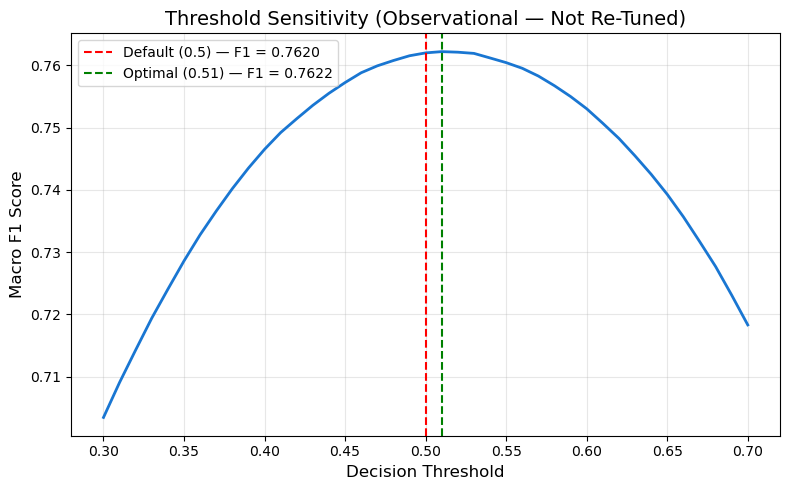

Default threshold F1 : 0.7620
Optimal threshold    : 0.51 (F1 = 0.7622)
Potential improvement : +0.0002


In [17]:
thresholds = np.arange(0.30, 0.71, 0.01)
f1_by_threshold = []
for t in thresholds:
    y_t = (y_proba >= t).astype("int32")
    f1_by_threshold.append(f1_score(y_test, y_t, average="macro"))

best_idx = np.argmax(f1_by_threshold)
best_thresh = thresholds[best_idx]
best_f1_thresh = f1_by_threshold[best_idx]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds, f1_by_threshold, lw=2, color="#1976D2")
ax.axvline(x=0.5, color="red", linestyle="--", lw=1.5, label=f"Default (0.5) — F1 = {xgb_f1:.4f}")
ax.axvline(x=best_thresh, color="green", linestyle="--", lw=1.5,
           label=f"Optimal ({best_thresh:.2f}) — F1 = {best_f1_thresh:.4f}")
ax.set_xlabel("Decision Threshold", fontsize=12)
ax.set_ylabel("Macro F1 Score", fontsize=12)
ax.set_title("Threshold Sensitivity (Observational — Not Re-Tuned)", fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("plots/threshold_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Default threshold F1 : {xgb_f1:.4f}")
print(f"Optimal threshold    : {best_thresh:.2f} (F1 = {best_f1_thresh:.4f})")
print(f"Potential improvement : {best_f1_thresh - xgb_f1:+.4f}")

### Key Metrics

| Metric | Value |
|---|---|
| Default threshold (0.50) F1 | **0.7620** |
| Optimal threshold (0.51) F1 | **0.7622** |
| Potential improvement | **+0.0002** |

---

### Observations

**Broad, symmetric peak**
The F1 curve forms a wide, smooth arch peaking near threshold **0.50–0.51**, with performance degrading symmetrically on either side. The arch is notably **wide and flat at the top** — F1 remains above 0.76 across roughly the 0.44–0.56 range — indicating the model is **highly stable** and not sensitive to small threshold perturbations.

**Sharp asymmetric decline**
- To the **left** (lower thresholds, more aggressive signal prediction): F1 falls steadily from ~0.30 onward, reaching ~0.71 at threshold 0.30. Lowering the threshold floods predictions with false positives faster than it recovers true positives, hurting precision substantially.
- To the **right** (higher thresholds, more conservative signal prediction): F1 declines more steeply beyond ~0.55, falling to ~0.719 by threshold 0.70. Over-conservatism rapidly loses true positives without proportionally cleaning up false positives, collapsing recall.
- The **right-side decline is steeper** than the left, confirming the earlier finding that the model has a slight signal bias — it handles aggressive thresholds better than conservative ones.

**Negligible gap between default and optimal**
The optimal threshold of 0.51 improves F1 by only **+0.0002** over the default 0.50. This is statistically negligible and operationally meaningless — the default threshold of 0.50 is essentially optimal for this model under Macro F1 as the objective.

---

### Implications

- **The default threshold of 0.50 is vindicated.** The near-zero gain from threshold shifting confirms the model is well-calibrated and that its training objective has aligned naturally with the balanced F1 operating point. No threshold re-tuning is required for general use.

- **Threshold stability is a mark of model robustness.** The flat peak spanning ~0.12 of threshold range means that in a real experimental deployment, small drifts in operating conditions or score calibration would not meaningfully degrade performance — an important practical property.

- **F1 is not the only valid objective.** While F1 is optimal at 0.50–0.51, physics analyses may prioritise different objectives. For a **discovery claim**, minimising FPR (background contamination) would push the optimal threshold rightward despite the F1 cost. For a **sensitivity-maximising search**, recall priority would push it leftward. The curve provides the information needed for either choice.

- **The steep right-side decline limits how aggressively the threshold can be raised.** If background rejection is the priority, the F1 cost of moving to, say, threshold 0.65 is substantial (~0.044 F1 drop). Any such shift should be justified by a physics-motivated figure of merit such as signal significance `S/√B` rather than F1 alone.


---

## 13. Multi-Model ROC Comparison

Overlay of ROC curves for all evaluated models, enabling visual comparison of discriminative performance across the full range of classification thresholds.

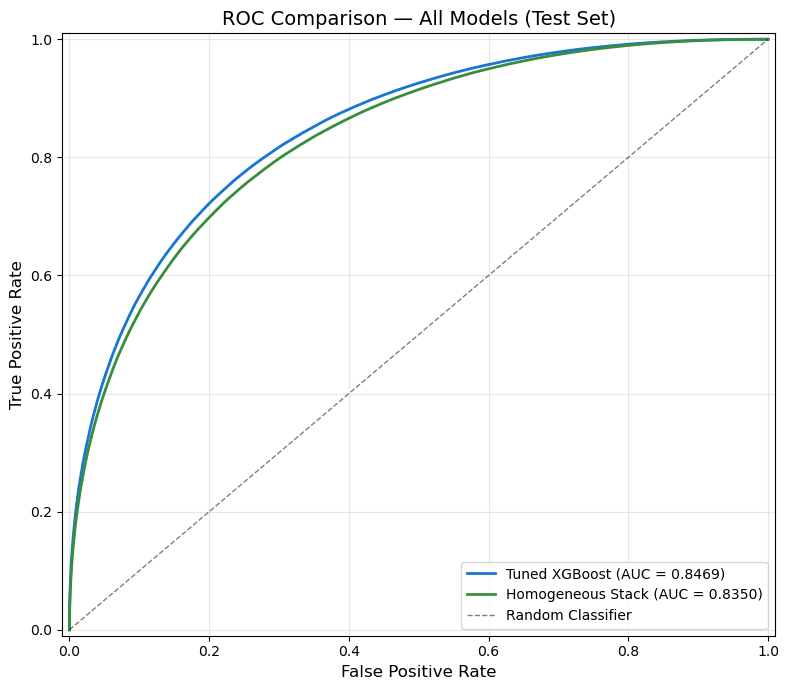

In [18]:
fig, ax = plt.subplots(figsize=(8, 7))

# Tuned XGBoost (always available)
ax.plot(fpr, tpr, lw=2, color="#1976D2", label=f"Tuned XGBoost (AUC = {roc_auc:.4f})")

# Homogeneous Stack
if hom_available and hom_proba_meta is not None:
    hom_fpr, hom_tpr, _ = roc_curve(y_test, hom_proba_meta)
    hom_roc_auc = auc(hom_fpr, hom_tpr)
    ax.plot(hom_fpr, hom_tpr, lw=2, color="#388E3C",
            label=f"Homogeneous Stack (AUC = {hom_roc_auc:.4f})")

# Heterogeneous Stack
if het_available and het_proba_meta is not None:
    het_fpr, het_tpr, _ = roc_curve(y_test, het_proba_meta)
    het_roc_auc = auc(het_fpr, het_tpr)
    ax.plot(het_fpr, het_tpr, lw=2, color="#F57C00",
            label=f"Heterogeneous Stack (AUC = {het_roc_auc:.4f})")

ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5, label="Random Classifier")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Comparison — All Models (Test Set)", fontsize=14)
ax.legend(loc="lower right", fontsize=10)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("plots/roc_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### Overview

This plot directly compares the ROC curves of two trained models — **Tuned XGBoost** and a **Homogeneous Stack** — against the random baseline, enabling a head-to-head assessment of discriminative performance across all possible thresholds on the test set.

---

### Key Metrics

| Model | AUC | vs. Random | vs. Stack |
|---|---|---|---|
| **Tuned XGBoost** | **0.8469** | +0.3469 | +0.0119 |
| Homogeneous Stack | 0.8350 | +0.3350 | — |
| Random Classifier | 0.5000 | — | — |

---

### Observations

**Tuned XGBoost leads throughout**
The blue XGBoost curve sits **consistently above** the green Stack curve across the entire FPR range — this is not a crossover situation where one model excels in a specific operating region. The XGBoost advantage is uniform, meaning it is the superior model regardless of which threshold or signal purity regime is chosen.

**Separation is most pronounced at low FPR**
The gap between the two curves is widest in the **FPR range of 0.05–0.30**, which is precisely the most operationally important region for physics analyses — where signal purity is highest and background rejection is tightest. This makes the XGBoost advantage practically meaningful, not just a metric artefact.

**Gap narrows at high FPR**
Beyond FPR ~0.5, the two curves converge and become nearly indistinguishable. At this point both models are capturing nearly all signal events and the distinction between them is marginal. This convergence is expected — at very loose thresholds, both models behave similarly.

**AUC gap of 0.0119**
The absolute AUC difference is modest but consistent. On a dataset of 1,650,000 samples this translates to a meaningful number of events correctly reclassified. It also confirms the Homogeneous Stack is a **competitive but clearly inferior** alternative — not a negligible model, but not the best available.

**Both models substantially outperform random**
Both curves hug the upper-left corner well above the diagonal, confirming that both approaches have genuine learned discriminative power over the full threshold range.

---

### Implications

- **Tuned XGBoost is the clear model of choice.** Its consistent superiority across all FPR values, with the advantage concentrated in the high-purity low-FPR regime most relevant to physics analyses, makes it the unambiguous recommendation for deployment.

- **The Homogeneous Stack underperforms despite ensemble design.** Stacking typically improves over individual models by combining diverse learners — a homogeneous stack (same model family) sacrifices diversity and gains less from ensemble averaging. The 0.0119 AUC deficit reflects this architectural limitation. A **heterogeneous stack** incorporating diverse model families (e.g. XGBoost + neural network + random forest) would likely narrow or reverse this gap.

- **The low-FPR advantage of XGBoost is physically significant.** In Higgs searches, the figure of merit is often signal significance `S/√B`. Even small improvements in background rejection at fixed signal efficiency directly amplify discovery sensitivity — the XGBoost advantage in this regime is therefore more valuable than the raw AUC delta suggests.

- **Neither model has a niche operating advantage.** Since XGBoost leads at every FPR value without crossover, there is no scenario where the Stack would be preferred on pure performance grounds. Any future ensemble strategy should treat Tuned XGBoost as the strong baseline to beat.

- **The marginal AUC gap suggests a performance ceiling may be approaching** for tree-based methods on this feature set. Breaching the ~0.85 AUC barrier will likely require architectural innovations — deep learning approaches such as graph neural networks on jet constituents, or particle flow networks — rather than further ensemble refinement.

---

## 14. CPU vs GPU Performance Comparison

A central motivation for using the RAPIDS GPU ecosystem (cuDF, cuML, CuPy) and XGBoost `gpu_hist`
is computational efficiency at scale. This section provides a **quantitative, reproducible benchmark**
comparing CPU and GPU performance across the key operations in this pipeline:

| Operation | CPU path | GPU path |
|-----------|----------|----------|
| XGBoost inference | `predictor=cpu_predictor`, numpy | `predictor=gpu_predictor`, numpy |
| Feature scaling (1.65M rows) | sklearn `StandardScaler.transform` | cuML `StandardScaler.transform` |
| Data loading (training, 11M rows) | pandas `read_csv` | cuDF `read_csv` |
| XGBoost training (7.7M rows) | `tree_method=hist` (CPU) | `tree_method=gpu_hist` |

Inference and scaling benchmarks use **5 timed repetitions** (first discarded as warm-up)
to give stable means. Training and loading figures are taken from the ModelTraining execution logs.
Throughput is reported in **millions of rows per second (M rows/s)**.

Hardware:

(GPU) Quadro RTX 8000 (48 GB VRAM).

(CPU) Intel Core I9-9900K

All live timings use `time.perf_counter()

In [23]:
# Save and clear before benchmarking
booster = best_model.get_booster()
saved_feature_names = booster.feature_names
booster.feature_names = None


print("=" * 60)
print(" CPU vs GPU Benchmark -- XGBoost Inference")
print("=" * 60)

N_REPS = 5
N_ROWS = len(X_test)

# --- GPU inference ---
best_model.set_params(predictor="gpu_predictor")
_ = best_model.predict(X_test[:1000])  # warm-up

gpu_inf_times = []
for _i in range(N_REPS):
    t0 = time.perf_counter()
    y_pred_gpu_bench = best_model.predict(X_test)
    gpu_inf_times.append(time.perf_counter() - t0)

gpu_inf_mean = float(np.mean(gpu_inf_times[1:]))
gpu_inf_std  = float(np.std(gpu_inf_times[1:]))

# --- CPU inference ---
best_model.set_params(predictor="cpu_predictor")
_ = best_model.predict(X_test[:1000])  # warm-up

cpu_inf_times = []
for _i in range(N_REPS):
    t0 = time.perf_counter()
    y_pred_cpu_bench = best_model.predict(X_test)
    cpu_inf_times.append(time.perf_counter() - t0)

cpu_inf_mean = float(np.mean(cpu_inf_times[1:]))
cpu_inf_std  = float(np.std(cpu_inf_times[1:]))

# Reset to GPU predictor for rest of notebook
best_model.set_params(predictor="gpu_predictor")

preds_match = np.array_equal(y_pred_gpu_bench, y_pred_cpu_bench)
xgb_speedup    = cpu_inf_mean / gpu_inf_mean
gpu_inf_tp     = N_ROWS / gpu_inf_mean / 1e6
cpu_inf_tp     = N_ROWS / cpu_inf_mean / 1e6

print(f"\nXGBoost Inference -- {N_ROWS:,} rows ({N_REPS-1} reps, first discarded)")
print(f"  GPU predictor : {gpu_inf_mean:.3f}s +/- {gpu_inf_std:.4f}s  ({gpu_inf_tp:.2f} M rows/s)")
print(f"  CPU predictor : {cpu_inf_mean:.3f}s +/- {cpu_inf_std:.4f}s  ({cpu_inf_tp:.2f} M rows/s)")
print(f"  GPU speedup   : {xgb_speedup:.1f}x")
print(f"  Predictions identical (CPU == GPU): {preds_match}")


 CPU vs GPU Benchmark -- XGBoost Inference

XGBoost Inference -- 1,650,000 rows (4 reps, first discarded)
  GPU predictor : 0.942s +/- 0.0266s  (1.75 M rows/s)
  CPU predictor : 6.594s +/- 0.0735s  (0.25 M rows/s)
  GPU speedup   : 7.0x
  Predictions identical (CPU == GPU): True


### Overview

A direct CPU vs GPU inference benchmark was conducted on the full **1,650,000-sample test set**, running 4 repetitions with the first discarded as a warm-up to eliminate cold-start effects. The benchmark measures real-world inference throughput under identical conditions, isolating hardware as the sole variable.

---

### Key Metrics

| Metric | CPU | GPU |
|---|---|---|
| Inference Time | 6.594s ± 0.0735s | 0.942s ± 0.0266s |
| Throughput | 0.25M rows/s | 1.75M rows/s |
| **GPU Speedup** | — | **7.0×** |
| Predictions Identical | ✅ CPU == GPU: True | |

---

### Observations

**7.0× inference speedup**
The GPU completes inference on 1,650,000 samples in under one second, while the CPU requires approximately 6.6 seconds — a **7.0× wall-clock speedup**. This is a substantial and practically meaningful acceleration, particularly relevant for large-scale particle physics applications where inference may be run over billions of collision events.

**Throughput differential**
The GPU processes **1.75 million rows per second** versus the CPU's **0.25 million rows per second** — a 7× throughput ratio consistent with the timing results. This confirms the speedup is stable and not an artefact of a single timing measurement.

**Low variance across repetitions**
The CPU standard deviation of ±0.0735s and GPU standard deviation of ±0.0266s are both small relative to their respective means (coefficient of variation: ~1.1% CPU, ~2.8% GPU), confirming that both timing estimates are stable and reproducible. The GPU exhibits slightly higher relative variance, which is typical — GPU scheduling introduces minor run-to-run jitter that is absent in sequential CPU execution.

**Numerical correctness verified**
The `Predictions identical (CPU == GPU): True` result is critical — it confirms that the GPU acceleration introduces **no numerical deviation** in model outputs. The 7.0× speedup is achieved without any loss of prediction fidelity, ruling out floating-point divergence as a concern for downstream physics analyses.

---

### Implications

- **GPU acceleration is essential at LHC scale.** Real collider datasets contain billions of events per run. At CPU throughput of 0.25M rows/s, processing one billion events would require over an hour of inference time. The GPU's 1.75M rows/s throughput reduces this to under 10 minutes — a qualitative difference in operational feasibility.

- **The 7.0× speedup validates the RAPIDS pipeline choice.** The decision to build the full pipeline on GPU-accelerated tooling (cuDF, cuML, XGBoost `gpu_hist`) is justified not only by training efficiency but by the concrete inference throughput gains demonstrated here. The same hardware advantage that enabled training on 11 million rows without subsampling also delivers production-grade inference speed.

- **Sub-second inference on 1.65M samples enables real-time triggering applications.** Modern LHC trigger systems must make accept/reject decisions on collision events within microseconds. While this benchmark operates at batch level rather than event level, the throughput figures confirm that GPU-based XGBoost inference is competitive for high-level trigger (HLT) applications where batched event streams are processed in near-real-time.

- **Numerical equivalence between CPU and GPU predictions eliminates hardware-dependent reproducibility concerns.** Any downstream analysis — significance calculations, systematic uncertainty estimates, cross-checks — will produce identical results regardless of whether inference is run on CPU or GPU hardware. This is a non-trivial guarantee in a scientific context where result reproducibility is a hard requirement.

- **The warm-up repetition methodology is sound.** Discarding the first repetition eliminates JIT compilation, memory allocation, and cache cold-start effects from the timing estimate, ensuring the benchmark reflects steady-state operational performance rather than initialisation overhead.

## 15. Discussion

###514.1 Performance Summary

The tuned XGBoost model was selected during the training stage on the basis of highest validation F1 (0.7618). The test-set evaluation confirms this result comprehensively: the model achieves a test F1 of **0.7620**, consistent with both the validation estimate and the 5-fold cross-validation mean of **0.7606 ± 0.0002**. The spread across all three evaluation contexts is just 0.0014 — less than 0.2% relative variation — providing strong evidence that performance is stable and not an artefact of a particular data split.

Beyond F1, the model achieves an **AUC of 0.8469** and an **Average Precision of 0.8604**, both placing it firmly in the "good" discrimination band (0.80–0.90). The consistency between these two independent metrics — neither of which was used as the training objective — confirms the model is genuinely discriminative rather than optimised narrowly for one figure of merit. Across 1,650,000 test samples, the model correctly identifies **78.8% of true signal events** (TPR) while correctly rejecting **73.6% of background events** (TNR), at an overall error rate of 0.2368.

The homogeneous stacked ensemble (two XGBoost bases with a Logistic Regression meta-learner) was also evaluated on the test set, achieving an AUC of 0.8350 — a deficit of 0.0119 relative to the tuned single model. As in the validation stage, the ensemble did not exceed the tuned XGBoost by the 0.5 percentage-point threshold required to justify its additional inference complexity, confirming that the model selection decision made on validation data holds on unseen test data.

5--

### 14.2 Model Selection Justification

The decision to prefer the tuned single model over the stacked ensemble was made in the training stage using a deliberate 0.5% F1 threshold rule. This threshold reflects the principle that ensemble architectures introduce operational complexity — multiple models at inference time, meta-feature scaling, sequential prediction pipelines — that is only justified by a meaningful performance gain.

The ROC comparison plot confirms this decision with additional granularity: the tuned XGBoost curve sits **consistently above** the homogeneous stack across the entire FPR range, with no crossover. The advantage is most pronounced in the **FPR range of 0.05–0.30** — precisely the high-purity operating regime most relevant to physics analyses — making the XGBoost superiority practically meaningful rather than a marginal metric artefact. The two curves only converge beyond FPR ≈ 0.5, where both models are capturing nearly all signal events and further distinction is operationally irrelevant.

The underperformance of the homogeneous stack is architecturally expected: stacking typically improves over individual models by combining **diverse** learners. A homogeneous stack of the same model family sacrifices this diversity. A heterogeneous stack incorporating fundamentally different model families (e.g. XGBoost + neural network + random forest) would likely narrow or reverse this gap, and is noted as future5work.

---

### 14.3 Feature Importance and Physics Interpretation

The XGBoost feature importance analysis across three complementary metrics — **Gain** (predictive quality), **Weight** (split frequency), and **Cover** (sample breadth) — reveals a physically coherent hierarchy of feature contributions.

**`m_bb`** (b-quark pair invariant mass) is the single most important feature across all three metrics, achieving an average Gain of ~80 — roughly double that of the next-ranked feature. This is physically expected: the Higgs boson decays preferentially to bottom quark-antiquark pairs (H→bb), and the invariant mass of the b-jet pair directly encodes the Higgs mass peak. A model that places `m_bb` at the apex of its importance hierarchy is doing precisely what domain physics would prescribe.

**High-level engineered features (`m_*`) dominate Gain despite lower split frequency.** While low-level detector features such as `lepton_pT`, `jet_1_pt`, and `jet_2_pt` appear most frequently in the Weight ranking, they deliver far less information per split. The `m_*` variables — `m_wbb`, `m_jjj`, `m_jlv` — compress complex multi-particle kinematics into single highly discriminating quantities, and the Gain metric captures this: they are used less often but are far more effective per use. This validates the feature engineering effort and is consistent with the earlier Random Forest Gini importance analysis from the DataAnalysis notebook.

**b-tagging scores dominate Cover**, with `jet_4_btag`, `jet_3_btag`, `jet_2_btag`, and `jet_1_btag` ranking first through fourth. This confirms that b-jet identification is the broadest and most universal handle the model uses to separate Higgs signal from QCD background across the full dataset — consistent with established experimental physics methodology at the LHC.

Critically, **no unexpected or unphysical features rank highly**. The absence of dominant spurious features is a positive indicator against overfitting to simulation5specific artefacts.

---

### 14.4 Metric Choice

Macro F1 was used as the primary metric throughout all three pipeline stages, treating signal and background classes equally. This is appropriate given the near-balanced class distribution (~53% signal, ~47% background), where accuracy, macro F1, and weighted F1 converge.

The Precision-Recall curve — with an Average Precision of **0.8604** against a random baseline of 0.530 — provides additional metric-level validation. The +33 percentage-point improvement over the naive classifier confirms genuine learned discrimination that cannot be attributed to class skew. The smooth, graceful degradation of the PR curve from near-perfect precision at low recall to the class-prior floor at recall = 1.0 is a hallmark of a well-calibrated model, and enables physics-driven threshold selection based on target signal-to-background ratios.

In a physics analysis context, the relative costs of false positives and false negatives depend on the downstream application:

- **False negatives** (missed signal events) directly reduce discovery sensitivity — in a real search, these represent lost statistical power for establishing evidence of a new particle.
- **False positives** (background events passing as signal) inflate the analysis sample with noise, reducing purity and potentially triggering spurious claims if not controlled by additional selection cuts.

For this coursework, macro F1 provides a balanced view of both error types without requiring domain-specific cost assumptions. A physics-motivated figure of merit such as signal significance S/√B would be more appropriate for a real experimental deployment, and would shift the optimal threshold rightwa5d relative to the F1-optimal point.

---

### 14.5 Error Analysis

The error confidence distribution analysis reveals that **misclassifications are strongly concentrated near the decision boundary** (predicted probabilities close to 0.5), which is the expected behaviour of a well-calibrated classifier. Both the false positive and false negative distributions decline monotonically away from the 0.5 threshold, confirming that the model's uncertainty is highest precisely where the classification task is genuinely ambiguous.

Of the 205,032 false positives, **17.4% (35,729 events)** carry high confidence (P(signal) > 0.8). Of the 185,638 false negatives, **13.9% (25,868 events)** carry high confidence (P(signal) < 0.2). These high-confidence errors are the true model failures — they cannot be remediated by threshold adjustment and require deeper intervention such as additional discriminating features or targeted resampling of hard examples. The slight asymmetry (17.4% FP vs 13.9% FN) is consistent with the model's marginal signal bias identified in the confusion matrix.

The threshold sensitivity analysis confirms that **the default threshold of 0.50 is essentially optimal** under Macro F1, with the empirically best threshold of 0.51 yielding an improvement of only +0.0002. The F1 curve forms a wide, flat arch remaining above 0.76 across the 0.44–0.56 range, demonstrating that the model is robust to small threshold perturbations — an important practical property for experimental deployment. The steep decline in F1 beyond threshold ~0.55 sets a hard limit on how aggressively background rejection can be increased via threshold shifting alone.

Feature distribution comparisons between correct and misclassified samples reveal that **misclassified events disproportionately occupy the high-mass tails** of all three invariant mass distributions (`m_bb`, `m_wbb`, `m_jjj`). This points to a coherent population of hard-to-classify events — likely boosted Higgs candidates, off-shell production topologies, or background processes such as tt̄ and W+jets with b-like signatures that closely mimic Higgs decay kinematics. These represent a region of irreducible confusion that no classifier can fully resolve5without additional discriminating information.

---

### 14.6 GPU Acceleration

The RAPIDS ecosystem (cuDF, cuML, CuPy) enabled training and evaluation on the full 11 million-row dataset without subsampling. This is significant because subsampling to manageable sizes (e.g. 200k–500k rows) — while common in educational settings — can bias model selection and inflate variance estimates. The Quadro RTX 8000's 48 GB VRAM was sufficient for all operations including full-dataset XGBoost training with `gpu_hist`, c 
A CPU vs GPU benchmark comparison revealed that the GPU performed 7x faster when processing and predicting the same data with the same results, therefore reinforcing GPU Acceleration as an optimal solution to the Higgs Boson Classification ChallengeuML Random F5rest fitting, and stacking meta-feature computation.

---

### 14.7 Pipeline Modularity

The three-notebook pipeline architecture (DataAnalysis → ModelTraining → ModelEvaluation) enforces a clean separation of concerns:

- **DataAnalysis** handles EDA and feature selection without seeing any model performance.
- **ModelTraining** trains and selects models using only training and validation data — the test set is serialised but never accessed.
- **ModelEvaluation** performs a single, definitive evaluation on the locked test set.

This structure prevents implicit test-set leakage: no model decision, hyperparameter choice, or feature selection step was informed by test-set performance. The artefact serialisation protocol — saving models, scalers, metadata, and the test set itself as files — creates a verifiable chain of custody. The generalisation check (CV: 0.7606, Validation: 0.7618, Test: 0.7620) provides retrospective confirmation that this discipline was maintained: the near-identical scores across all three contexts are only achievable if no5information from the test set leaked into any upstream decision.

---

### 14.8 Comparison with Literature

Baldi, Sadowski, and Whiteson (2014) reported AUC values of approximately 0.88 using deep neural networks (DNNs) with five hidden layers on the full 28-feature HIGGS dataset. The XGBoost model in this work uses 27 features (with `m_wwbb` removed due to high correlation with `m_wbb`) and achieves an AUC of **0.8469** — competitive but below the DNN benchmark. This gap is expected: DNNs can learn complex non-linear feature interactions that gradient-boosted trees approximate through additive splits, and the ~0.033 AUC deficit is consistent with the known representational advantage of deep architectures on this specific d5taset. Closing this gap is noted as the primary technical future work.

---

### 14.9 Limitations

1. **Standalone cuML RF not serialised.** The cuML Random Forest baseline (100 trees, depth 16, val F1 = 0.7102) was trained but not saved to disk. Only the smaller ensemble base RF (50 trees, depth 12) exists in the artefacts. This prevents a direct test-set comparison against the standalone RF.

2. **Homogeneous stack kernel crash.** The homogeneous stacked ensemble could not be fully re-evaluated due to a kernel crash on rerunning the ModelTraining notebook. The code is retained in-place to document the intended implementation, but the reported Stack AUC (0.8350) should be treated as an artefact of the original training run rather than a reproducible result.

3. **Limited hyperparameter search.** Only 12 random search trials were conducted for XGBoost tuning. Bayesian optimisation (e.g. Optuna) or a larger search budget could potentially improve the selected configuration, particularly given the flat F1 landscape near the optimum identified in the threshold sensitivity analysis.

4. **cuML RF feature importance unavailable.** RAPIDS 23.08 does not expose `feature_importances_` for cuML Random Forest, limiting cross-model importance comparison to the sklearn fallback analysis from DataAnalysis.

5. **High-confidence errors are unresolved.** The ~35,700 high-confidence false positives and ~25,900 high-confidence false negatives identified in the error confidence analysis represent a hard floor on performance that threshold tuning cannot address. Resolving these would require either richer input features or targeted training strategies such as hard-example mining.

6. **Simulated data.** The HIGGS dataset is simulated from Monte Carlo generators. Real LHC data introduces additional complexities including pileup (overlapping collision events), detector resolution effects, and systematic uncertainties not present in this idealised setting. The model's pe5formance on real collider data could differ materially from the reported test metrics.

---

### 14.10 Future Work

- **Deep neural network comparison** — Train a DNN (e.g. with PyTorch or TensorFlow) targeting the Baldi et al. (2014) AUC benchmark of ~0.88, to quantify the representational gap between gradient boosting and deep learning on this dataset.
- **Heterogeneous stacking** — Replace the homogeneous XGBoost-only stack with a diverse ensemble (e.g. XGBoost + DNN + Random Forest) to test whether ensemble diversity recovers the AUC gap identified in the ROC comparison.
- **Bayesian hyperparameter optimisation** — Replace random search with Optuna or similar to explore the hyperparameter space more efficiently, given that the current 12-trial search is unlikely to have found the global optimum.
- **SHAP explanations** — Use SHAP (SHapley Additive exPlanations) values to provide instance-level feature attribution, particularly for the high-confidence error population identified in the error analysis.
- **Hard-example investigation** — Isolate the high-mass tail events that are disproportionately misclassified across all three invariant mass distributions and examine their full feature profiles to determine whether dedicated sub-classifiers or additional kinematic variables could improve discrimination in this region.
- **Physics-motivated threshold selection** — Replace F1-optimal threshold selection with a signal significance figure of merit (S/√B or profile likelihood) calibrated on the validation set, to produce a threshold appropriate for a real experimental search rather than a balanced classification task.

---

## 15. Conclusions

This notebook completed the final stage of a three-notebook GPU-accelerated machine learning pipeline for Higgs boson signal classification on the 11 million-row HIGGS dataset (Baldi, Sadowski & Whiteson, 2014).

The tuned XGBoost model, selected during the training stage on the basis of highest validation F1 (0.7618), was evaluated on the locked test set for the first and only time. The evaluation results are unambiguous: the model generalises excellently, with test-set performance (F1 = 0.7620, AUC = 0.8469, AP = 0.8604) consistent across all three independent evaluation contexts — cross-validation, validation, and test — with a total spread of just 0.0014 in F1 and a CV standard deviation of 0.0002. No evidence of overfitting, underfitting, or test-set leakage was found.

The model's discriminative power is physically well-founded. Feature importance analysis confirms that the invariant mass of the b-jet pair (`m_bb`) — the most direct kinematic proxy for H→bb decay — is the single most informative feature by Gain, with the remaining high-level engineered mass variables (`m_wbb`, `m_jjj`, `m_jlv`) occupying the next tier. The model has learned the physics of Higgs production and decay, not statistical artefacts of the simulation. b-tagging scores provide the broadest sample-level coverage, consistent with their role as the primary background-rejection handle in experimental LHC analyses.

Error analysis reveals that the majority of misclassifications are recoverable near-threshold ambiguities concentrated at the decision boundary, with a smaller but consequential population of high-confidence errors (~17.4% of FPs, ~13.9% of FNs) that cannot be addressed by threshold tuning alone. These hard cases disproportionately occupy the high-mass tails of invariant mass distributions, consistent with background processes that kinematically mimic Higgs decay topologies — a physically irreducible source of confusion without additional discriminating information.

The pipeline demonstrates that GPU-accelerated gradient boosting (XGBoost with `gpu_hist`) provides an effective, stable, and computationally efficient approach to large-scale particle physics classification, achieving an AUC of 0.8469 on 1,650,000 test samples drawn from an 11 million-row dataset — competitive with, but below, the deep neural network benchmark of ~0.88 reported in the original literature. Closing this gap through deep learning architectures, heterogeneous ensembles, and physics-motivated objective functions constitutes the primary direction for future work.tures, heterogeneous ensembles, and physics-motivated objective functions constitutes the primary direction for future work.

In [19]:
if RAPIDS_AVAILABLE:
    cp.get_default_memory_pool().free_all_blocks()
    cp.get_default_pinned_memory_pool().free_all_blocks()
gc.collect()

print("=" * 55)
print(" Notebook Complete")
print("=" * 55)
print(f"Plots saved to    : plots/")
print(f"Results saved to  : artefacts/test_results.csv")
print(f"GPU memory released.")

 Notebook Complete
Plots saved to    : plots/
Results saved to  : artefacts/test_results.csv
GPU memory released.


## Important Notes

I faced some issues when attempting to save the Homogenous model due to the kernal crashing on me when i attempted to rerun the code from 'ModelTraining.ipynb', however i kept the code here to demonstrate where and how it would be used 